In [38]:
import matplotlib.pyplot as plt
import os

if os.path.exists("../stylesheet.mplstyle"):
    plt.style.use("../stylesheet.mplstyle")  

In [39]:
import json
results_horse_race = {}
datasets = set()
with open('../data/raw/OC-space_paper_compression.txt', 'r') as file: #Load in the XGB classification results
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())

        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        results_horse_race[key] = line_dict
        datasets.add(line_dict['dname'])

datasets = sorted(list(datasets))

In [40]:
enumerations_file = '../results/main_paper_enumeration.txt'
enumeration_results = {}
with open(enumerations_file, 'r') as file: #Load in the enumeration results
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        enumeration_results[key] = line_dict



In [41]:
closest_adv_file = '../results/main_paper_verification.txt'
closest_adv_results = {}
with open(closest_adv_file, 'r') as file: #Load in the closest adversarial results
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        closest_adv_results[key] = line_dict

In [42]:
import prada
import util
import pandas as pd

ds_names = {
    'Adult': 'Adult',
    'Vehicle': 'Vehicle',
    'Electricity': 'Electricity',
    'Volkert[2v7]': 'Volkert',
    'CompasTwoYears': 'Compas',
    'Credit': 'Credit',
    'DryBean[6vRest]': 'DryBean',
    'California': 'California',
    'FashionMnist[1vRest]': 'FashionMnist',
    'HiggsBig': 'Higgs',
    'Ijcnn1': 'Ijcnn',
    'Jannis': 'Jannis',
    'MiniBooNE': 'MiniBooNE',
    'Phoneme': 'Phoneme',
    'Spambase': 'Spambase',
    'Mnist[2v4]': 'Mnist',
}

rows = []
for ds in datasets:
    d = prada.get_dataset(ds, seed=util.SEED, silent=True)
    d.load_dataset()
    rows.append({
        "Name": ds_names.get(ds),
        "\# samples": int(d.X.shape[0]),
        "\# features": int(d.X.shape[1]),
        f'$\\alpha$': d.y.mean()
    })

dsets_df = pd.DataFrame(rows)[["Name", "\# samples", "\# features", f'$\\alpha$']]
caption = "Properties of the datasets: Name, number of examples, number of features, and class prior $\\alpha$ (i.e., proportion of positive examples)."
latex = dsets_df.to_latex(index=False, caption=caption, label="tab:datasets", float_format="%.2f")
print(latex)


\begin{table}
\caption{Properties of the datasets: Name, number of examples, number of features, and class prior $\alpha$ (i.e., proportion of positive examples).}
\label{tab:datasets}
\begin{tabular}{lrrr}
\toprule
Name & \# samples & \# features & $\alpha$ \\
\midrule
Adult & 48842 & 32 & 0.24 \\
California & 20634 & 8 & 0.50 \\
Compas & 4966 & 11 & 0.50 \\
Credit & 16714 & 10 & 0.50 \\
DryBean & 13611 & 16 & 0.19 \\
Electricity & 38474 & 8 & 0.50 \\
FashionMnist & 70000 & 784 & 0.10 \\
Higgs & 940160 & 24 & 0.50 \\
Ijcnn & 141691 & 22 & 0.10 \\
Jannis & 57580 & 54 & 0.50 \\
MiniBooNE & 72998 & 50 & 0.50 \\
Mnist & 13814 & 784 & 0.49 \\
Phoneme & 5404 & 5 & 0.71 \\
Spambase & 4601 & 57 & 0.39 \\
Vehicle & 846 & 18 & 0.49 \\
Volkert & 24325 & 180 & 0.53 \\
\bottomrule
\end{tabular}
\end{table}



In [43]:
import pandas as pd
# Group enumeration results by dataset and calculate statistics
summary_data = []

for dname in sorted(set(result['dname'] for result in enumeration_results.values())):
    dataset_results = [r for r in enumeration_results.values() if r['dname'] == dname]
    
    # Find max OC space that was fully enumerated
    enumerated_results = [r for r in dataset_results if not r['enumeration'].get('failed', True)]
    
    if enumerated_results:
        max_enumerated = max(enumerated_results, key=lambda x: x['enumeration']['oc_space'])
        max_oc_space = max_enumerated['enumeration']['oc_space']
        elapsed = max_enumerated['enumeration']['elapsed']

    else:
        max_oc_space = None
        elapsed = None
    
    # Calculate percentage enumerated
    total_count = len(dataset_results)
    enumerated_count = len(enumerated_results)
    enumerated_pct = (enumerated_count / total_count * 100) if total_count > 0 else 0
    
    summary_data.append({
        'Dataset': ds_names.get(dname, dname),
        'Enumerated': enumerated_count,
        'Total': total_count,
        'Percentage': enumerated_pct,
        r'Max $|\mathcal{O}|$': max_oc_space,
        # 'Elapsed (s)': elapsed,
    })
summary_data.append({
    'Dataset': 'Total',
    'Enumerated': sum(d['Enumerated'] for d in summary_data),
    'Total': sum(d['Total'] for d in summary_data),
    'Percentage': sum(d['Enumerated'] for d in summary_data) / sum(d['Total'] for d in summary_data) * 100 if sum(d['Total'] for d in summary_data) > 0 else 0,
    r'Max $|\mathcal{O}|$': '-',
    # 'Elapsed (s)': '-'
})

summary_df = pd.DataFrame(summary_data)
caption = "Enumeration statistics per dataset showing number of Pareto front configurations successfully enumerated and their maximum OC-space size. The models are obtained by compressing them with two rounds of LOP with an allowed balanced accuracy drop of $0.005$."
def sci_fmt(x):
    try:
        return f"{float(x):.2e}"
    except Exception:
        return str(x)

print(summary_df.to_latex(
    index=False,
    caption=caption,
    label="tab:enumeration_stats_0005",
    float_format="%.1f",
    formatters={r'Max $|\mathcal{O}|$': sci_fmt}
    
))

\begin{table}
\caption{Enumeration statistics per dataset showing number of Pareto front configurations successfully enumerated and their maximum OC-space size. The models are obtained by compressing them with two rounds of LOP with an allowed balanced accuracy drop of $0.005$.}
\label{tab:enumeration_stats_0005}
\begin{tabular}{lrrrl}
\toprule
Dataset & Enumerated & Total & Percentage & Max $|\mathcal{O}|$ \\
\midrule
Adult & 70 & 70 & 100.0 & 9.45e+07 \\
California & 70 & 70 & 100.0 & 2.59e+09 \\
Compas & 55 & 55 & 100.0 & 2.48e+02 \\
Credit & 60 & 60 & 100.0 & 3.75e+05 \\
DryBean & 35 & 35 & 100.0 & 1.56e+03 \\
Electricity & 98 & 115 & 85.2 & 3.23e+09 \\
FashionMnist & 53 & 55 & 96.4 & 3.41e+09 \\
Higgs & 55 & 105 & 52.4 & 1.47e+10 \\
Ijcnn & 75 & 125 & 60.0 & 1.24e+10 \\
Jannis & 38 & 60 & 63.3 & 5.81e+09 \\
MiniBooNE & 39 & 80 & 48.8 & 1.55e+10 \\
Mnist & 39 & 40 & 97.5 & 1.85e+09 \\
Phoneme & 85 & 85 & 100.0 & 8.14e+07 \\
Spambase & 30 & 30 & 100.0 & 4.97e+07 \\
Vehicle & 35 & 35

In [44]:
#Calculate the maximum OC-space size across all enumerated results
max_oc_space = max(
    (enumeration_results[k]['enumeration']['oc_space'] 
     for k in closest_adv_results.keys() 
     if k in enumeration_results),
    default=None
)
print(f"Maximum OC-space size: {max_oc_space}")

Maximum OC-space size: 94517128


In [45]:
rows = []

for dname in sorted(set(r["dname"] for r in enumeration_results.values())):
    ds_results = [
        r for r in enumeration_results.values()
        if r["dname"] == dname and not r["enumeration"].get("failed", True)
    ]
    total = len(ds_results)
    smaller = sum(1 for r in ds_results if r["enumeration"]["oc_space"] < max_oc_space)

    rows.append({
        "Dataset": ds_names.get(dname, dname),
        "Enumerated": total,
        f"OC-space < {max_oc_space}": smaller,
        "Percentage": (smaller / total * 100) if total > 0 else 0.0,
    })

counts_df = pd.DataFrame(rows)
print(counts_df.to_latex(index=False, float_format="%.1f"))
counts_df
oc_col = next(c for c in counts_df.columns if c.startswith("OC-space <"))
total_enumerated = counts_df["Enumerated"].sum()
total_smaller = counts_df[oc_col].sum()
total_percentage = (total_smaller / total_enumerated * 100) if total_enumerated else 0.0

print(f"Total enumerable percentage: {total_percentage:.1f}%")

\begin{tabular}{lrrr}
\toprule
Dataset & Enumerated & OC-space < 94517128 & Percentage \\
\midrule
Adult & 70 & 69 & 98.6 \\
California & 70 & 69 & 98.6 \\
Compas & 55 & 55 & 100.0 \\
Credit & 60 & 60 & 100.0 \\
DryBean & 35 & 35 & 100.0 \\
Electricity & 98 & 78 & 79.6 \\
FashionMnist & 53 & 43 & 81.1 \\
Higgs & 55 & 36 & 65.5 \\
Ijcnn & 75 & 60 & 80.0 \\
Jannis & 38 & 34 & 89.5 \\
MiniBooNE & 39 & 28 & 71.8 \\
Mnist & 39 & 37 & 94.9 \\
Phoneme & 85 & 85 & 100.0 \\
Spambase & 30 & 30 & 100.0 \\
Vehicle & 35 & 34 & 97.1 \\
Volkert & 45 & 43 & 95.6 \\
\bottomrule
\end{tabular}

Total enumerable percentage: 90.2%


In [46]:
import veritas

rows = []

for dname in sorted(set(r["dname"] for r in enumeration_results.values())):
    enumerated = [
        r for r in enumeration_results.values()
        if r["dname"] == dname and not r["enumeration"].get("failed", True)
    ]
    
    if not enumerated:
        continue

    largest = max(
        enumerated,
        key=lambda r: (r["enumeration"]["oc_space"])
    )

    key = f"{largest['dname']}_{largest['params']['n_estimators']}_{largest['params']['max_depth']}_{largest['params']['learning_rate']}_{largest['fold']}"
    model = results_horse_race.get(key).get('refinements')[0]['model_json']
    model = veritas.AddTree.from_json(model)

    rows.append({
        "Dataset": ds_names.get(dname, dname),
        "M": len(model),
        "D": model.max_depth(),
        r'\#Leaves': model.num_leafs(),
        r'Max $|\mathcal{O}|$': largest["enumeration"]["oc_space"],
    })

largest_models_df = pd.DataFrame(rows).sort_values("Dataset").reset_index(drop=True)
caption = 'Largest enumerated model per dataset showing model characteristics: M denotes the number of trees, D is the maximum depth of a tree and $|\ocspace|$ is the size of its OC space.'
label = 'tab:largest_enumerated_models'
print(largest_models_df.to_latex(index=False, caption=caption, label=label, formatters={r'Max $|\mathcal{O}|$': sci_fmt}))

\begin{table}
\caption{Largest enumerated model per dataset showing model characteristics: M denotes the number of trees, D is the maximum depth of a tree and $|\ocspace|$ is the size of its OC space.}
\label{tab:largest_enumerated_models}
\begin{tabular}{lrrrr}
\toprule
Dataset & M & D & \#Leaves & Max $|\mathcal{O}|$ \\
\midrule
Adult & 27 & 4 & 109 & 9.45e+07 \\
California & 39 & 4 & 489 & 2.59e+09 \\
Compas & 6 & 4 & 30 & 2.48e+02 \\
Credit & 17 & 4 & 75 & 3.75e+05 \\
DryBean & 6 & 4 & 33 & 1.56e+03 \\
Electricity & 67 & 4 & 612 & 3.23e+09 \\
FashionMnist & 9 & 6 & 155 & 3.41e+09 \\
Higgs & 39 & 4 & 194 & 1.47e+10 \\
Ijcnn & 23 & 4 & 238 & 1.24e+10 \\
Jannis & 20 & 4 & 127 & 5.81e+09 \\
MiniBooNE & 16 & 4 & 124 & 1.55e+10 \\
Mnist & 12 & 4 & 101 & 1.85e+09 \\
Phoneme & 44 & 8 & 1135 & 8.14e+07 \\
Spambase & 16 & 4 & 80 & 4.97e+07 \\
Vehicle & 37 & 6 & 171 & 2.52e+09 \\
Volkert & 7 & 6 & 239 & 1.10e+09 \\
\bottomrule
\end{tabular}
\end{table}



/tmp/ipykernel_282033/3329617621.py:61: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


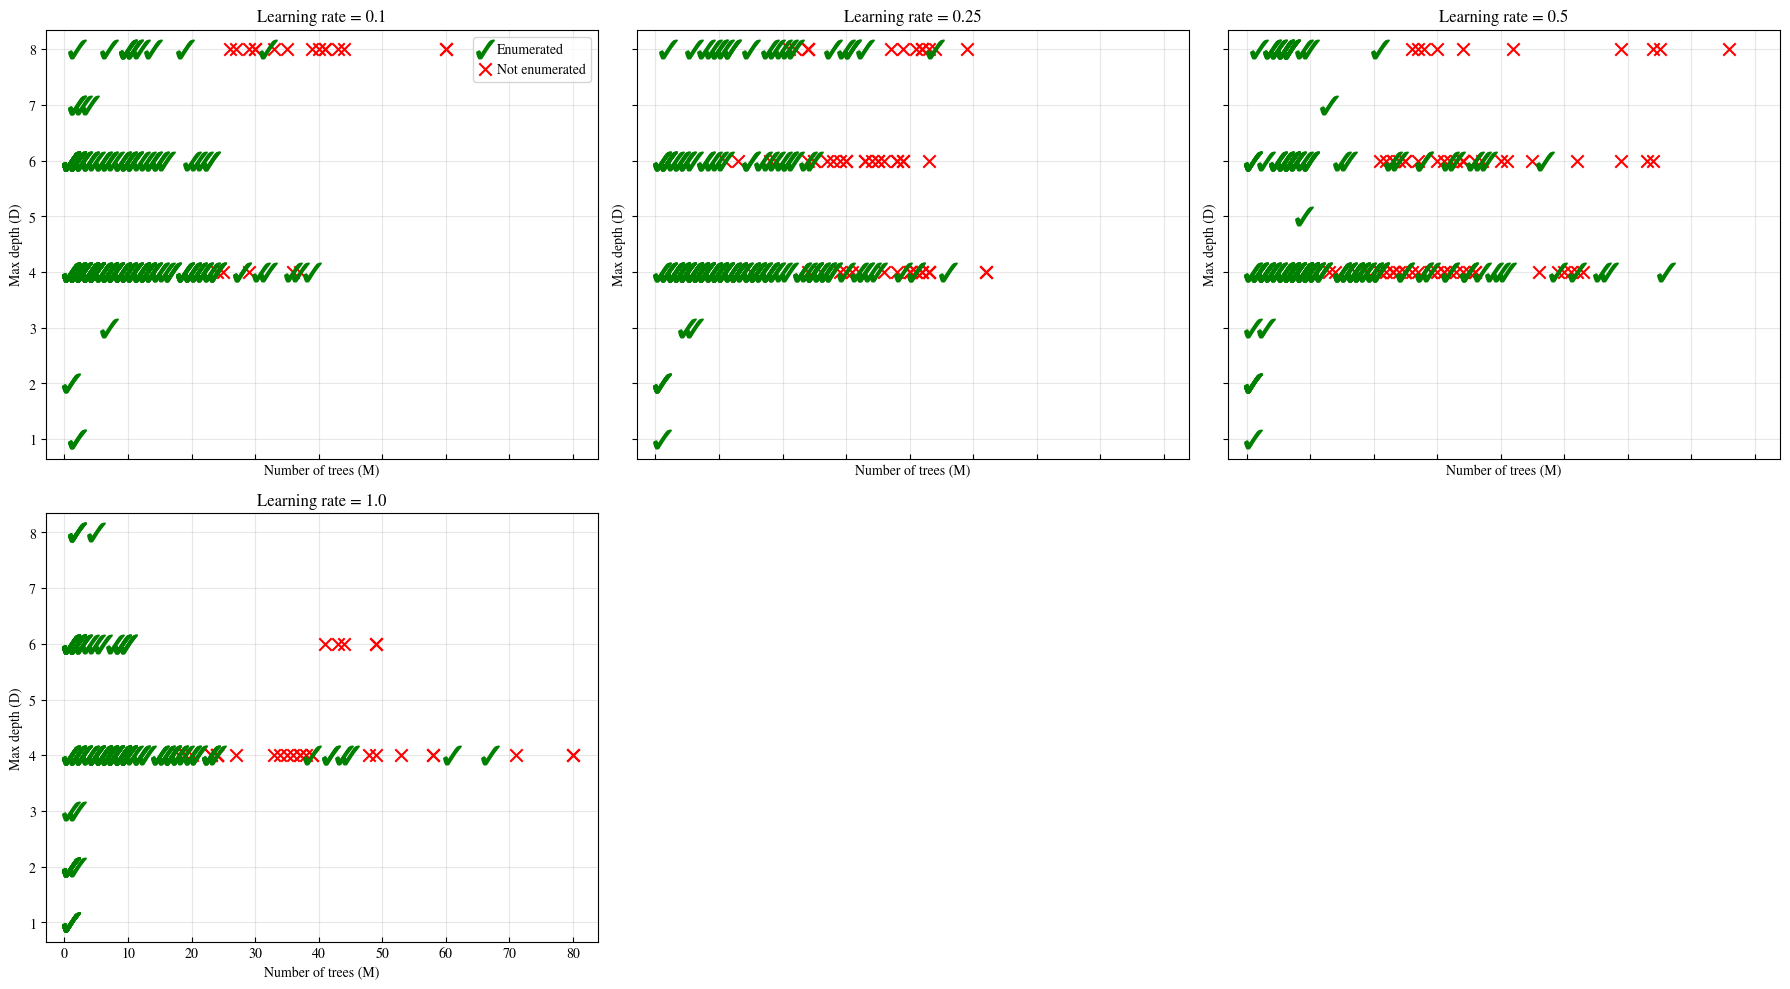

In [47]:
import numpy as np

learning_rates = sorted(
    {
        res.get("params", {}).get("learning_rate")
        for key, res in results_horse_race.items()
        if key in enumeration_results
    }
)

n = len(learning_rates)
n_cols = min(3, n)
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, lr in enumerate(learning_rates):
    ax = axes[i]
    trees, depths, enum_flags = [], [], []

    for key, res in results_horse_race.items():
        if key not in enumeration_results:
            continue

        params = res.get("params", {}) or {}
        if params.get("learning_rate") != lr:
            continue

        model_json = res.get("refinements", [{}])[0].get("model_json")
        if model_json is None:
            continue

        model = veritas.AddTree.from_json(model_json)
        M = len(model)
        D = model.max_depth()
        trees.append(M)
        depths.append(D)

        er = enumeration_results.get(key)
        enum_flags.append(bool(er and not er.get("enumeration", {}).get("failed", True)))

    trees = np.array(trees)
    depths = np.array(depths)
    enum_flags = np.array(enum_flags, dtype=bool)

    ax.scatter(trees[enum_flags], depths[enum_flags], marker=u'$\u2713$', s=180, color='green', label='Enumerated', zorder=3)
    ax.scatter(trees[~enum_flags], depths[~enum_flags], marker='x', s=80, color='red', label='Not enumerated', zorder=2)

    ax.set_title(f"Learning rate = {lr}")
    ax.set_xlabel("Number of trees (M)")
    ax.set_ylabel("Max depth (D)")
    ax.grid(True, alpha=0.3)

    if i == 0:
        ax.legend()

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("../plots/models_enumeration_status_by_learning_rate.pdf", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_282033/1739815393.py:58: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


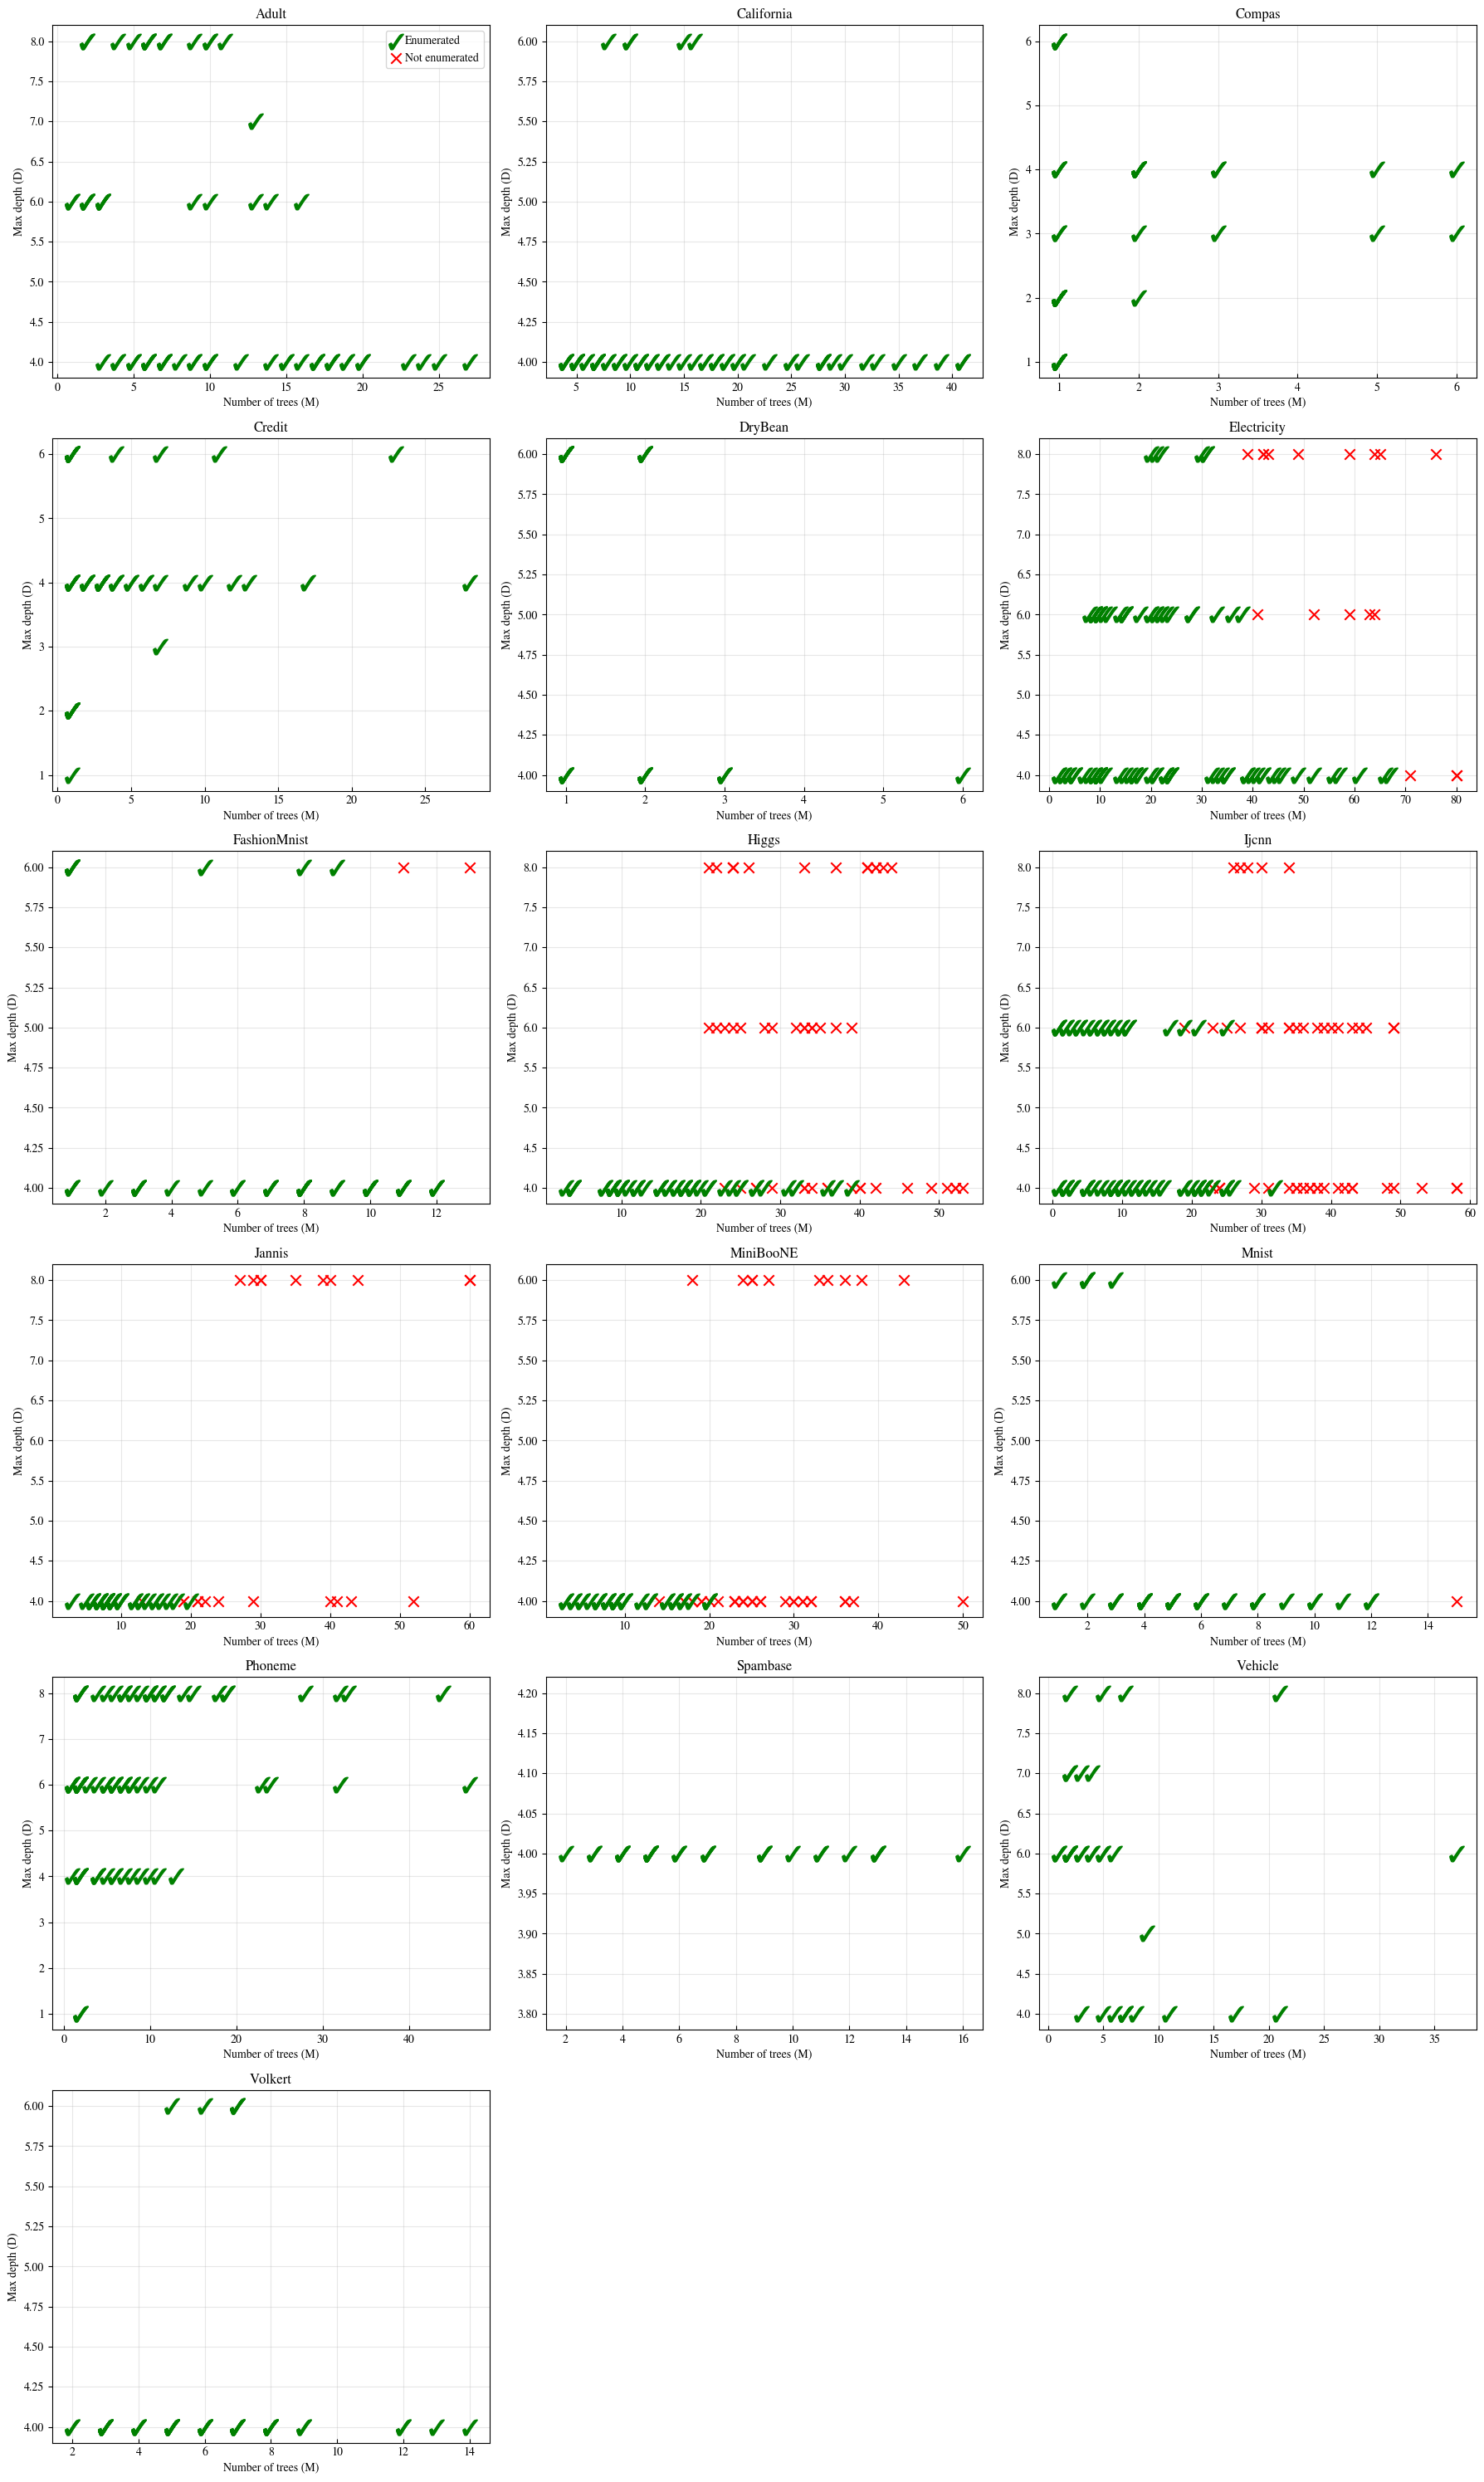

In [48]:
import numpy as np

dataset_list = sorted(
    {
        res.get("dname")
        for key, res in results_horse_race.items()
        if key in enumeration_results
    }
)

n = len(dataset_list)
n_cols = min(3, n)
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, ds in enumerate(dataset_list):
    ax = axes[i]
    trees, depths, enum_flags = [], [], []

    for key, res in results_horse_race.items():
        if key not in enumeration_results:
            continue

        if res.get("dname") != ds:
            continue

        model_json = res.get("refinements", [{}])[0].get("model_json")
        if model_json is None:
            continue

        model = veritas.AddTree.from_json(model_json)
        trees.append(len(model))
        depths.append(model.max_depth())

        er = enumeration_results.get(key)
        enum_flags.append(bool(er and not er.get("enumeration", {}).get("failed", True)))

    trees = np.array(trees)
    depths = np.array(depths)
    enum_flags = np.array(enum_flags, dtype=bool)

    ax.scatter(trees[enum_flags], depths[enum_flags], marker=u'$\u2713$', s=180, color='green', label='Enumerated', zorder=3)
    ax.scatter(trees[~enum_flags], depths[~enum_flags], marker='x', s=80, color='red', label='Not enumerated', zorder=2)

    ax.set_title(ds_names.get(ds, ds))
    ax.set_xlabel("Number of trees (M)")
    ax.set_ylabel("Max depth (D)")
    ax.grid(True, alpha=0.3)

    if i == 0:
        ax.legend()

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("../plots/models_enumeration_status_by_dataset.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [49]:
import veritas
def bound_oc_space(at):
    splits = at.get_splits()
    bound_1 = 1
    for _, f_values in splits.items():
        bound_1 *= (len(f_values) + 1)

    bound_2 = 1
    for t in at:
        bound_2 *= (t.num_leaves())
    return bound_1, bound_2

rows = []
for key in enumeration_results:
    if enumeration_results[key]['enumeration'].get('failed'):
        continue
    model = results_horse_race[key]['refinements'][0]['model_json']
    model = veritas.AddTree.from_json(model)

    feature_bound, leaf_bound = bound_oc_space(model)
    rows.append({
        "Dataset": key.split('_')[0],
        "Feature Bound": feature_bound,
        "Leaf Bound": leaf_bound,
        'OC Space': enumeration_results[key]['enumeration']['oc_space']
    })
    assert enumeration_results[key]['enumeration']['oc_space'] <= feature_bound
    assert enumeration_results[key]['enumeration']['oc_space'] <= leaf_bound

df = pd.DataFrame(rows)

/tmp/ipykernel_282033/4284644744.py:54: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.05, hspace=0.2)
/tmp/ipykernel_282033/4284644744.py:54: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.05, hspace=0.2)
/tmp/ipykernel_282033/4284644744.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.83])


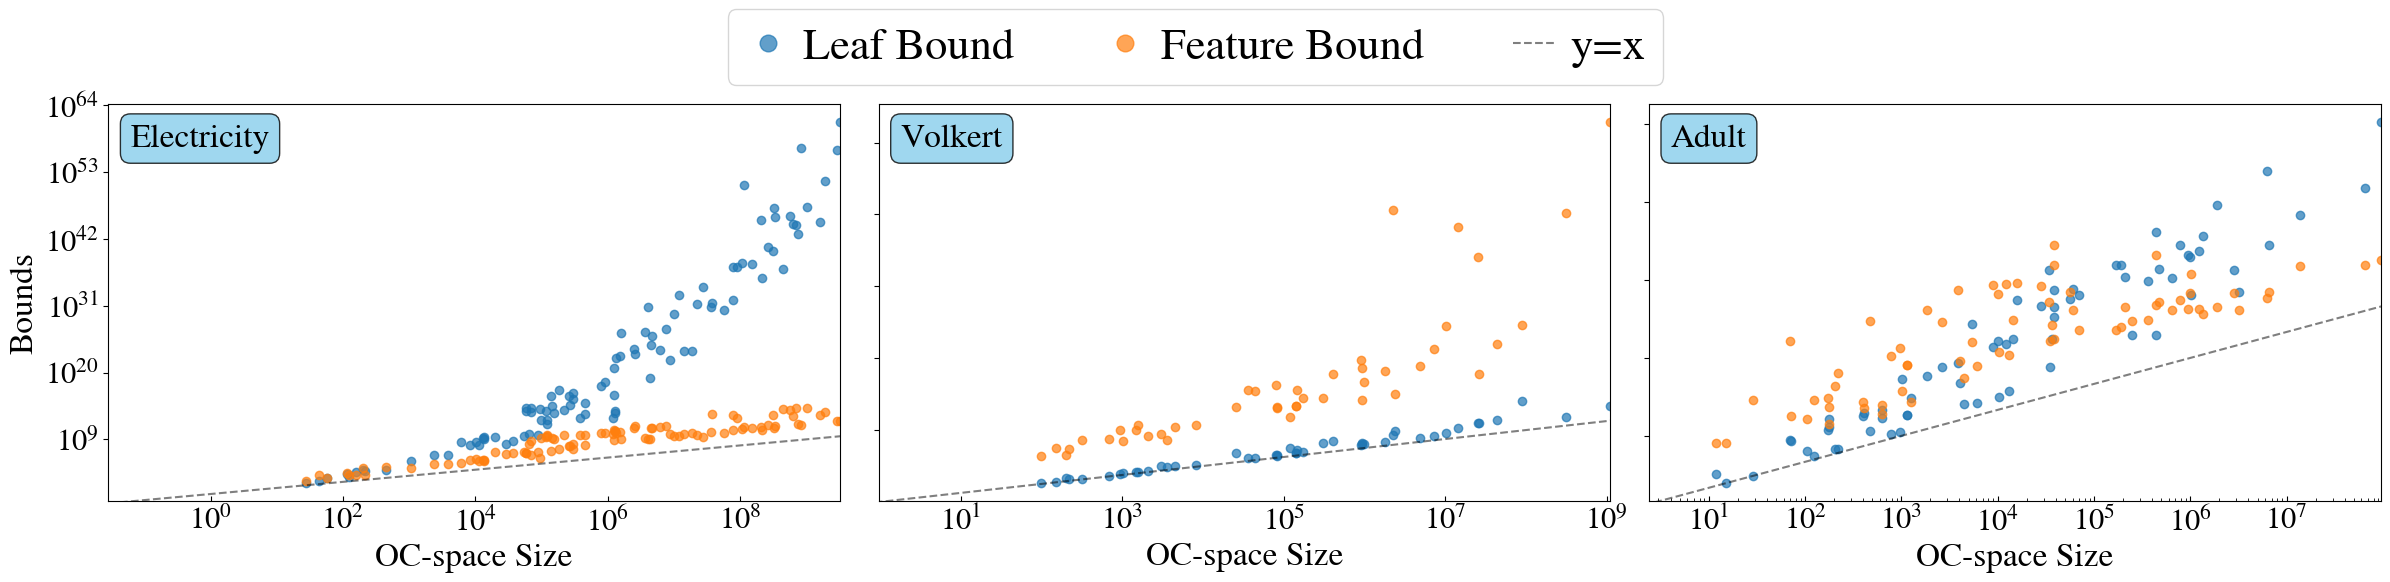

In [50]:
from matplotlib import pyplot as plt
dataset_subset = ['Electricity', 'Volkert[2v7]', 'Adult']

# Calculate grid dimensions
n_datasets = len(dataset_subset)
n_cols = min(3, n_datasets)  # Max 3 columns
n_rows = (n_datasets + n_cols - 1) // n_cols  # Calculate rows needed

# Create subplots in matrix format
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 6*n_rows))

# Handle single subplot case
if n_datasets == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# Flatten for easier indexing
axes_flat = axes.flatten() if n_datasets > 1 else axes

for d, ds in enumerate(dataset_subset):
    _df = df[df['Dataset'] == ds]

    oc_space_sizes = _df['OC Space'].tolist()
    bounds_n_leafs = _df['Leaf Bound'].tolist()
    bounds_n_feature_splits = _df['Feature Bound'].tolist()
    # print(f"Dataset: {ds}, OC Space Sizes: {oc_space_sizes}, Leaf Bounds: {bounds_n_leafs}, Feature Bounds: {bounds_n_feature_splits}")

    axes_flat[d].plot(oc_space_sizes, bounds_n_leafs, 'o', label='Leaf Bound', alpha=0.7)
    axes_flat[d].plot(oc_space_sizes, bounds_n_feature_splits, 'o', label='Feature Bound', alpha=0.7)
    axes_flat[d].text(0.03, 0.95, f"{ds_names[ds]}", transform=axes_flat[d].transAxes, 
                      verticalalignment='top', horizontalalignment='left',
                      bbox=dict(boxstyle='round', facecolor='skyblue', alpha=0.8), fontsize=24)
    axes_flat[d].plot()
    # axes_flat[d].set_title(f"Dataset: {ds}")
    axes_flat[d].set_xlabel('OC-space Size', fontsize=24)
    # axes_flat[d].set_ylabel('Bounds')
    axes_flat[d].set_xscale('log')
    axes_flat[d].set_yscale('log')
    axes_flat[d].tick_params(axis='both', which='major', labelsize=22)
    # Only show y-axis label and ticks on leftmost plots
    if d % n_cols == 0:  # leftmost column
        axes_flat[d].set_ylabel('Bounds', fontsize=24)
    else:
        axes_flat[d].set_ylabel('')
        axes_flat[d].set_yticklabels([])
        # Remove space between subplots
        if d % n_cols != n_cols - 1 and d != len(dataset_subset) - 1:  # Not rightmost column and not last plot
            axes_flat[d].tick_params(right=False)
        
        # Remove space between plots more aggressively
        plt.subplots_adjust(wspace=0.05, hspace=0.2)

    # Add diagonal reference line
    lim = max(max(bounds_n_leafs), max(bounds_n_feature_splits), max(oc_space_sizes))
    axes_flat[d].plot([0, lim], [0, lim], 'k--', alpha=0.5, label='y=x')
    axes_flat[d].set_xlim(right=max(oc_space_sizes))
    # axes_flat[d].set_ylim(bottom=1e-1, top=max(max(bounds_n_leafs), max(bounds_n_feature_splits)))

# Create a single legend for the entire figure
handles, labels = axes_flat[0].get_legend_handles_labels()

fig.tight_layout(rect=[0, 0, 1, 0.83])
fig.legend(handles, labels, bbox_to_anchor=(0.5, 1), loc='upper center', ncol=3, fontsize=32, markerscale=2)

# plt.tight_layout()
plt.savefig('../plots/pareto_front_bounds_vs_oc_space.pdf', dpi=300, bbox_inches='tight')


82.1% within 1 minute (724/882)
88.3% within 5 minutes (779/882)


/tmp/ipykernel_282033/3172448778.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


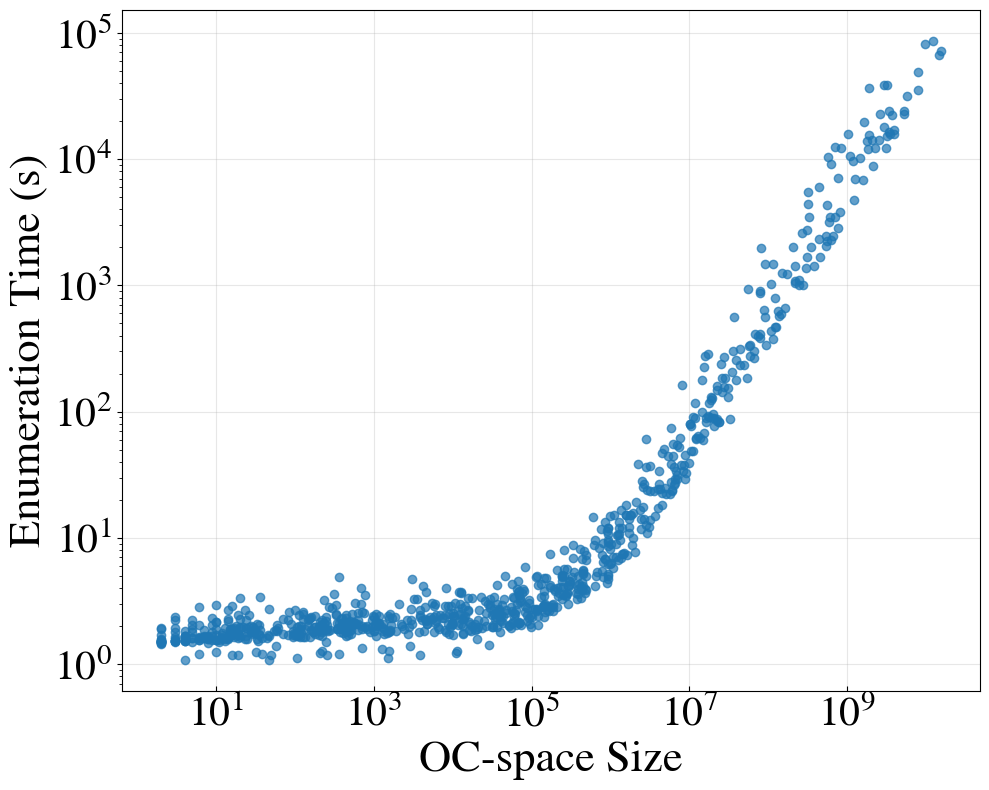

In [51]:
from matplotlib import pyplot as plt

rows = []
for key in enumeration_results:
    if enumeration_results[key]['enumeration'].get('failed'):
        continue

    rows.append({
        "Dataset": key.split('_')[0],
        "enumeration_time": enumeration_results[key]['enumeration']['elapsed'],
        'OC Space': enumeration_results[key]['enumeration']['oc_space']
    })

df = pd.DataFrame(rows)

n = len(df)
within_1m = sum(1 for v in df['enumeration_time'] if v <= 60)
within_5m = sum(1 for v in df['enumeration_time'] if v <= 300)
print(f"{within_1m/n*100:.1f}% within 1 minute ({within_1m}/{n})")
print(f"{within_5m/n*100:.1f}% within 5 minutes ({within_5m}/{n})")

plt.figure(figsize=(10, 8))
plt.plot(df['OC Space'], df['enumeration_time'], 'o', alpha=0.7)
plt.xlabel('OC-space Size', fontsize=32)
plt.ylabel('Enumeration Time (s)', fontsize=32)
plt.xscale('log')
plt.yscale('log')
plt.tick_params(axis='both', which='major', labelsize=30)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/pareto_front_enumeration_times_combined.pdf', dpi=300, bbox_inches='tight')
plt.show()


### The next part describes the enumeration results if allowed bacc drop in LOP would be increased to 0.01

In [52]:
enumerations_file_appendix = '../results/enumerate_001_bacc_loss.txt'
enumeration_results_appendix = {}
with open(enumerations_file_appendix, 'r') as file: #Load in the enumeration results
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        enumeration_results_appendix[key] = line_dict

In [53]:
import pandas as pd
# Group enumeration results by dataset and calculate statistics
summary_data = []

for dname in sorted(set(result['dname'] for result in enumeration_results_appendix.values())):
    dataset_results = [r for r in enumeration_results_appendix.values() if r['dname'] == dname]
    
    # Find max OC space that was fully enumerated
    enumerated_results = [r for r in dataset_results if not r['enumeration'].get('failed', True)]
    
    if enumerated_results:
        max_enumerated = max(enumerated_results, key=lambda x: x['enumeration']['oc_space'])
        max_oc_space = max_enumerated['enumeration']['oc_space']
        elapsed = max_enumerated['enumeration']['elapsed']

    else:
        max_oc_space = None
        elapsed = None
    
    # Calculate percentage enumerated
    total_count = len(dataset_results)
    enumerated_count = len(enumerated_results)
    enumerated_pct = (enumerated_count / total_count * 100) if total_count > 0 else 0
    
    summary_data.append({
        'Dataset': ds_names.get(dname, dname),
        'Enumerated': enumerated_count,
        'Total': total_count,
        'Percentage': enumerated_pct,
        r'Max $|\mathcal{O}|$': max_oc_space,
        # 'Elapsed (s)': elapsed,
    })
summary_data.append({
    'Dataset': 'Total',
    'Enumerated': sum(d['Enumerated'] for d in summary_data),
    'Total': sum(d['Total'] for d in summary_data),
    'Percentage': sum(d['Enumerated'] for d in summary_data) / sum(d['Total'] for d in summary_data) * 100 if sum(d['Total'] for d in summary_data) > 0 else 0,
    r'Max $|\mathcal{O}|$': '-',
    # 'Elapsed (s)': '-'
})

summary_df = pd.DataFrame(summary_data)

caption = "Enumeration statistics per dataset showing number of Pareto front configurations successfully enumerated and their maximum OC-space size. The models are obtained by compressing them with three rounds of LOP with an allowed balanced accuracy drop of $0.01$."
def sci_fmt(x):
    try:
        return f"{float(x):.2e}"
    except Exception:
        return str(x)

print(summary_df.to_latex(
    index=False,
    caption=caption,
    label="tab:enumeration_stats_001",
    float_format="%.1f",
    formatters={r'Max $|\mathcal{O}|$': sci_fmt}))

\begin{table}
\caption{Enumeration statistics per dataset showing number of Pareto front configurations successfully enumerated and their maximum OC-space size. The models are obtained by compressing them with three rounds of LOP with an allowed balanced accuracy drop of $0.01$.}
\label{tab:enumeration_stats_001}
\begin{tabular}{lrrrl}
\toprule
Dataset & Enumerated & Total & Percentage & Max $|\mathcal{O}|$ \\
\midrule
Adult & 50 & 50 & 100.0 & 2.79e+03 \\
California & 90 & 90 & 100.0 & 1.91e+09 \\
Compas & 40 & 40 & 100.0 & 5.70e+01 \\
Credit & 50 & 50 & 100.0 & 6.72e+03 \\
DryBean & 60 & 60 & 100.0 & 4.00e+02 \\
Electricity & 100 & 110 & 90.9 & 4.72e+09 \\
FashionMnist & 35 & 35 & 100.0 & 6.99e+05 \\
Higgs & 70 & 110 & 63.6 & 1.23e+10 \\
Ijcnn & 78 & 115 & 67.8 & 1.67e+10 \\
Jannis & 52 & 70 & 74.3 & 2.60e+09 \\
MiniBooNE & 50 & 95 & 52.6 & 1.70e+10 \\
Mnist & 45 & 45 & 100.0 & 1.27e+07 \\
Phoneme & 95 & 95 & 100.0 & 1.51e+08 \\
Spambase & 54 & 55 & 98.2 & 1.45e+07 \\
Vehicle & 40 & 

85.0% within 1 minute (811/954)
87.8% within 5 minutes (838/954)


/tmp/ipykernel_282033/2963517938.py:29: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


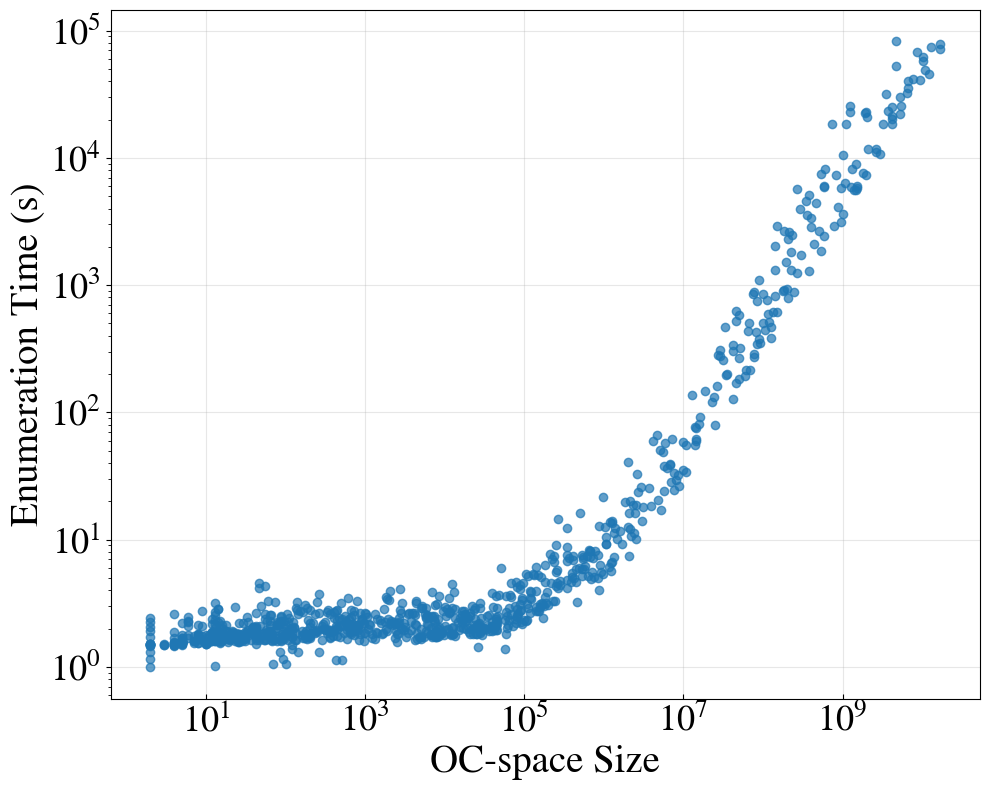

In [54]:
from matplotlib import pyplot as plt

rows = []
for key in enumeration_results_appendix:
    if enumeration_results_appendix[key]['enumeration'].get('failed'):
        continue
    rows.append({
        "Dataset": key.split('_')[0],
        "enumeration_time": enumeration_results_appendix[key]['enumeration']['elapsed'],
        'OC Space': enumeration_results_appendix[key]['enumeration']['oc_space']
    })

df = pd.DataFrame(rows)

n = len(df)
within_1m = sum(1 for v in df['enumeration_time'] if v <= 60)
within_5m = sum(1 for v in df['enumeration_time'] if v <= 300)
print(f"{within_1m/n*100:.1f}% within 1 minute ({within_1m}/{n})")
print(f"{within_5m/n*100:.1f}% within 5 minutes ({within_5m}/{n})")

plt.figure(figsize=(10, 8))
plt.plot(df['OC Space'], df['enumeration_time'], 'o', alpha=0.7)
plt.xlabel('OC-space Size', fontsize=28)
plt.ylabel('Enumeration Time (s)', fontsize=28)
plt.xscale('log')
plt.yscale('log')
plt.tick_params(axis='both', which='major', labelsize=26)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/pareto_front_enumeration_times_combined_appendix.pdf', dpi=300, bbox_inches='tight')
plt.show()


# Index building results

In [55]:
from scipy.stats import gmean
summary_data = []

for dname in sorted(set(result['dname'] for result in closest_adv_results.values())):
    verified_results = [r for r in closest_adv_results.values() if r['dname'] == dname and not r['verification'].get('failed_oc', False)]
    
    if verified_results:
        max_rootbox = max(verified_results, key=lambda x: x['verification']['rootbox_index']['index_building_time'])
        max_time_rootbox = max_rootbox['verification']['rootbox_index']['index_building_time']
        geom_mean_time_rootbox = gmean([r['verification']['rootbox_index']['index_building_time'] for r in verified_results])

        max_octree = max(verified_results, key=lambda x: x['verification']['octree_index']['index_building_time'])
        max_time_octree = max_octree['verification']['octree_index']['index_building_time']
        geom_mean_time_octree = gmean([r['verification']['octree_index']['index_building_time'] for r in verified_results])
    summary_data.append({
        'Dataset': ds_names.get(dname, dname),
        'Geometric Mean rootbox': geom_mean_time_rootbox,
        'Max Time rootbox': max_time_rootbox,
        'Geometric Mean octree': geom_mean_time_octree,
        'Max Time octree': max_time_octree,
    })

summary_df = pd.DataFrame(summary_data)


In [56]:
import matplotlib.pyplot as plt

# gather rootbox index build times (seconds) from closest_adv_results
root_times = []
for item in closest_adv_results.values():
    # print(item)
    vr = item.get('verification')
    
    if isinstance(vr.get('rootbox_index'), dict):
        t = vr['rootbox_index'].get('index_building_time')
    
    try:
        root_times.append(float(t))
    except Exception:
        continue

if not root_times:
    print("No rootbox index build times found")
else:
    n = len(root_times)
    within_1m = sum(1 for v in root_times if v <= 60)
    within_5m = sum(1 for v in root_times if v <= 300)
    print(f"{within_1m/n*100:.1f}% within 1 minute ({within_1m}/{n})")
    print(f"{within_5m/n*100:.1f}% within 5 minutes ({within_5m}/{n})")

plot_df = summary_df[summary_df["Dataset"] != "Total"].copy()
x = range(len(plot_df))


96.3% within 1 minute (463/481)
99.4% within 5 minutes (478/481)


In [57]:
import matplotlib.pyplot as plt

# gather octree index build times (seconds) from verification_results
octree_times = []
for item in closest_adv_results.values():
    vr = item.get('verification')
    
    if isinstance(vr.get('octree_index'), dict):
        t = vr['octree_index'].get('index_building_time')
    
    try:
        octree_times.append(float(t))
    except Exception:
        continue

if not octree_times:
    print("No octree index build times found")
else:
    n = len(octree_times)
    within_1m = sum(1 for v in octree_times if v <= 60)
    within_5m = sum(1 for v in octree_times if v <= 300)
    print(f"{within_1m/n*100:.1f}% within 1 minute ({within_1m}/{n})")
    print(f"{within_5m/n*100:.1f}% within 5 minutes ({within_5m}/{n})")
    

93.8% within 1 minute (451/481)
97.9% within 5 minutes (471/481)


/tmp/ipykernel_282033/2795711487.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=18)
/tmp/ipykernel_282033/2795711487.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


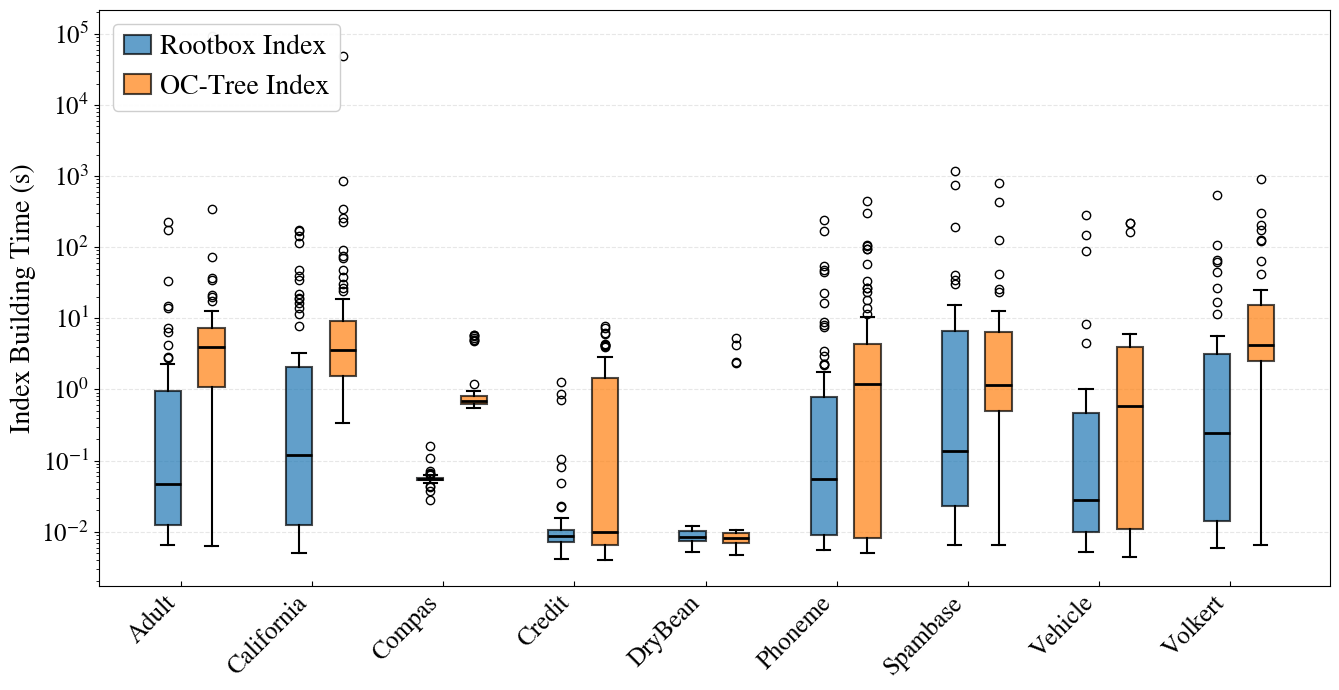

In [58]:
from matplotlib import pyplot as plt

# Boxplots per dataset: rootbox vs octree index build times

# Use summary_df order (pretty names) and ds_names mapping from earlier cell
pretty_to_raw = {v: k for k, v in ds_names.items()}
datasets_order = summary_df["Dataset"].tolist()

root_groups = []
oct_groups = []
labels = []

for pretty in datasets_order:
    raw = pretty_to_raw.get(pretty, pretty)
    root_times = []
    oct_times = []
    for item in closest_adv_results.values():
        if item.get("dname") != raw:
            continue
        vr = item.get("verification", {}) or {}
        r = vr.get("rootbox_index")
        o = vr.get("octree_index")
        try:
            if isinstance(r, dict) and r.get("index_building_time") is not None:
                root_times.append(float(r["index_building_time"]))
        except Exception:
            pass
        try:
            if isinstance(o, dict) and o.get("index_building_time") is not None:
                oct_times.append(float(o["index_building_time"]))
        except Exception:
            pass

    if not root_times and not oct_times:
        continue
    labels.append(pretty)
    root_groups.append(root_times if root_times else [float("nan")])
    oct_groups.append(oct_times if oct_times else [float("nan")])

if not labels:
    print("No index build times found per dataset.")
else:
    n = len(labels)
    positions = [i * 3 for i in range(n)]
    pos_root = positions
    pos_oct = [p + 1 for p in positions]

    fig, ax = plt.subplots(figsize=(max(12, n * 1.5), 7))
    bp_root = ax.boxplot(root_groups, positions=pos_root, widths=0.6, patch_artist=True, manage_ticks=False,
                          boxprops=dict(linewidth=1.5), whiskerprops=dict(linewidth=1.5), 
                          capprops=dict(linewidth=1.5), medianprops=dict(linewidth=2, color='black'))
    bp_oct = ax.boxplot(oct_groups, positions=pos_oct, widths=0.6, patch_artist=True, manage_ticks=False,
                         boxprops=dict(linewidth=1.5), whiskerprops=dict(linewidth=1.5),
                         capprops=dict(linewidth=1.5), medianprops=dict(linewidth=2, color='black'))

    # Professional color scheme
    for b in bp_root["boxes"]:
        b.set(facecolor="#1f77b4", alpha=0.7)
    for b in bp_oct["boxes"]:
        b.set(facecolor="#ff7f0e", alpha=0.7)

    ax.set_xticks([p + 0.3 for p in positions])
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=18)
    ax.set_yticklabels(ax.get_yticks(), fontsize=18)
    ax.set_yscale("log")
    ax.set_ylabel("Index Building Time (s)", fontsize=20)
    # ax.set_xlabel("Dataset", fontsize=14)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    
    # Professional legend
    handles = [bp_root["boxes"][0], bp_oct["boxes"][0]]
    ax.legend(handles, ["Rootbox Index", "OC-Tree Index"], loc="upper left", fontsize=20, framealpha=0.95)

    plt.tight_layout()
    plt.savefig("../plots/rootbox_vs_octree_index_build_times_per_dataset.pdf", dpi=300, bbox_inches="tight")
    plt.show()

## Closest adversarial example

In [59]:
import numpy as np
from scipy.stats import gmean

summary_data = []
for dname in sorted(set(r["dname"] for r in closest_adv_results.values())):
    verified_results = [r for r in closest_adv_results.values() if r['dname'] == dname and not r['verification'].get('failed_oc', False)]

    if verified_results:
        geom_mean_time_rootbox = gmean([np.mean(r['verification']['rootbox_index']['individual_verification_times']) for r in verified_results]) * 1000
        geom_mean_time_octree = gmean([np.mean(r['verification']['octree_index']['individual_verification_times']) for r in verified_results]) * 1000
        geom_mean_time_kantchelian = gmean([np.mean(r['verification']['kantchelian']['individual_verification_times']) for r in verified_results]) * 1000
        geom_mean_time_linear_scan = gmean([np.mean(r['verification']['linear_scan']['individual_verification_times']) for r in verified_results]) * 1000
        summary_data.append({
            'Dataset': ds_names.get(dname, dname),
            'Kantchelian': geom_mean_time_kantchelian,
            'Linear Scan': geom_mean_time_linear_scan,
            'Rootbox': geom_mean_time_rootbox,
            'OC-Tree': geom_mean_time_octree,
        })

df = pd.DataFrame(summary_data)
print(df.to_latex(index=False, float_format="%.3f", caption="Geometric mean of empirical robustness verification times (in seconds) across all verified configurations per dataset. Only configurations for which OC-space enumeration and verification succeeded are included.", label="tab:verification_times_geometric_mean"))

\begin{table}
\caption{Geometric mean of empirical robustness verification times (in seconds) across all verified configurations per dataset. Only configurations for which OC-space enumeration and verification succeeded are included.}
\label{tab:verification_times_geometric_mean}
\begin{tabular}{lrrrr}
\toprule
Dataset & Kantchelian & Linear Scan & Rootbox & OC-Tree \\
\midrule
Adult & 7.153 & 0.696 & 0.390 & 1.515 \\
California & 12.407 & 2.376 & 0.208 & 1.687 \\
Compas & 1.932 & 0.008 & 0.365 & 1.208 \\
Credit & 3.418 & 0.018 & 0.056 & 0.027 \\
DryBean & 3.559 & 0.014 & 0.052 & 0.008 \\
Phoneme & 24.504 & 0.482 & 0.265 & 0.467 \\
Spambase & 5.545 & 1.327 & 0.326 & 0.493 \\
Vehicle & 6.287 & 0.366 & 0.186 & 0.170 \\
Volkert & 8.319 & 4.885 & 0.697 & 1.927 \\
\bottomrule
\end{tabular}
\end{table}



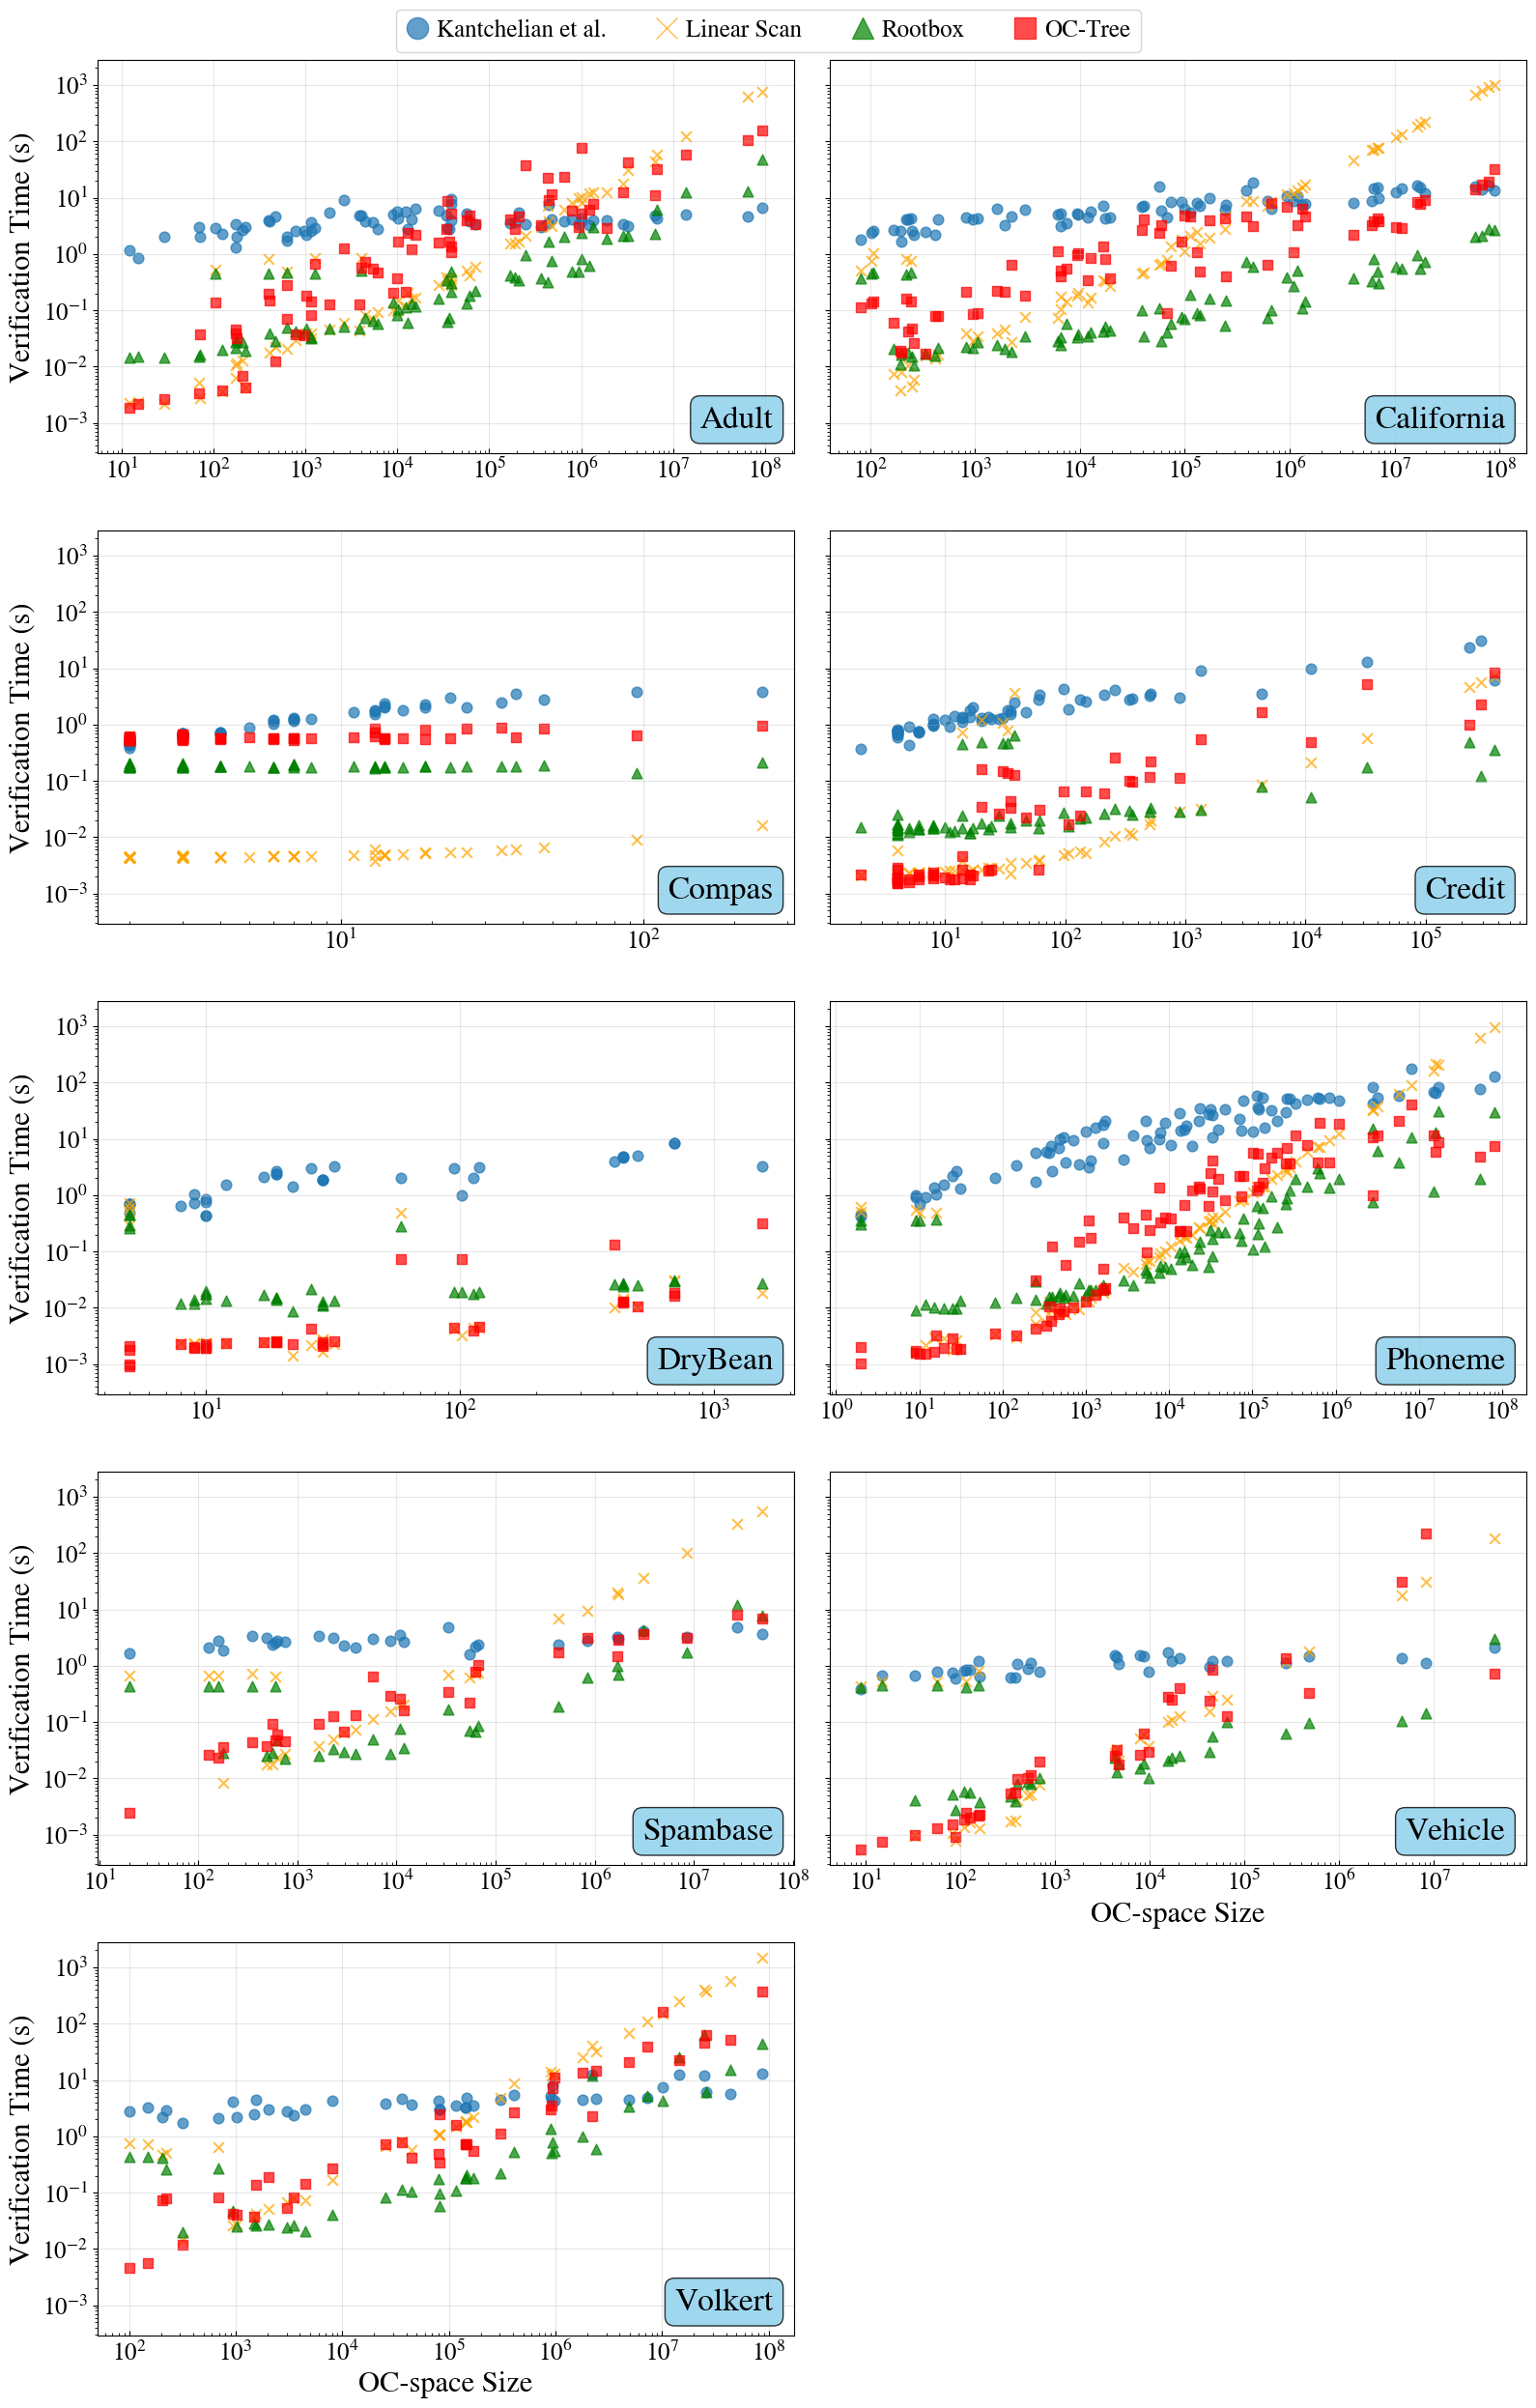

In [60]:
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

datasets_to_include = ['Credit', 'Adult', 'Vehicle', 'Spambase', 'Phoneme', 'DryBean[6vRest]', 'Volkert[2v7]', 'California', 'CompasTwoYears']
# datasets_to_include = ['California', 'Phoneme']


# Calculate grid dimensions
n_datasets = len(datasets_to_include)
n_cols = min(2, n_datasets)  # Max 2 columns
n_rows = (n_datasets + n_cols - 1) // n_cols  # Calculate rows needed

# Create subplots in matrix format
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 5*n_rows), constrained_layout=False)

# Handle single subplot case
if n_datasets == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# Flatten for easier indexing
axes_flat = axes.flatten() if n_datasets > 1 else axes

for d, ds in enumerate(sorted(datasets_to_include)):
    if ds not in datasets_to_include:
        continue

    verified_results = [(key, value) for key, value in closest_adv_results.items() if value['dname'] == ds and not value['verification'].get('failed_oc', False)]

    oc_space_sizes = [enumeration_results[k]['enumeration']['oc_space'] for k, _ in verified_results]
    kantchelian_times = [r['verification']['kantchelian']['emp_rob_time'] for _, r in verified_results]
    linear_scan_times = [r['verification']['linear_scan']['emp_rob_time'] for _, r in verified_results]
    rootbox_times = [r['verification']['rootbox_index']['emp_rob_time'] for _, r in verified_results]
    oc_index_times = [r['verification']['octree_index']['emp_rob_time'] for _, r in verified_results]


    axes_flat[d].scatter(oc_space_sizes, kantchelian_times,  label='Kantchelian et al.', alpha=0.7, s=60)
    axes_flat[d].scatter(oc_space_sizes, linear_scan_times, marker='x', color='orange', label='Linear Scan', alpha=0.7, s=60)
    axes_flat[d].scatter(oc_space_sizes, rootbox_times, marker='^', color='green', label='Rootbox index', alpha=0.7, s=60)
    axes_flat[d].scatter(oc_space_sizes, oc_index_times, marker='s', color='red', label='OCTree index', alpha=0.7, s=60)
    # axes_flat[d].scatter(oc_space_sizes, veritas_times, marker='d', color='purple', label='Veritas', alpha=0.7, s=60)
    axes_flat[d].text(0.97, 0.05, f"{ds_names[ds]}", transform=axes_flat[d].transAxes, 
                      verticalalignment='bottom', horizontalalignment='right',
                      bbox=dict(boxstyle='round', facecolor='skyblue', alpha=0.8), fontsize=24)
    axes_flat[d].set_xlabel('OC-space Size', fontsize=22)
    axes_flat[d].grid(True, alpha=0.3 )
    
            
    axes_flat[d].set_xscale('log')
    axes_flat[d].set_yscale('log')
    axes_flat[d].tick_params(axis='both', which='major', labelsize=18)
    # Only show y-axis label and ticks on leftmost plots
    if d % n_cols == 0:  # leftmost column
        axes_flat[d].set_ylabel('Verification Time (s)', fontsize=22)
    else:
        axes_flat[d].tick_params(labelleft=False)

    # Only keep x-axis label on the bottom row (bottom two plots for 2 columns)
    if d < len(datasets_to_include) - n_cols:
        axes_flat[d].set_xlabel('')
    else:
        axes_flat[d].set_xlabel('OC-space Size', fontsize=22)

    # After the last subplot is populated, force a common y-range across all subplots
    if d == len(datasets_to_include) - 1:
        y_lims = [ax.get_ylim() for ax in axes_flat[:len(datasets_to_include)]]
        common_ymin = min(lim[0] for lim in y_lims if lim[0] > 0)
        common_ymax = max(lim[1] for lim in y_lims)

        for ax in axes_flat[:len(datasets_to_include)]:
            ax.set_ylim(common_ymin, common_ymax)

        # Remove extra empty axes (if grid > number of datasets)
        for ax in axes_flat[len(datasets_to_include):]:
            ax.set_visible(False)

    


import matplotlib.patches as mpatches
kantchelian_line = Line2D([0], [0], marker='o', label='Kantchelian et al.', linestyle='None', markersize=16, alpha=0.7,)
linear_scan_line = Line2D([0], [0], marker='x', color='orange', label='Linear Scan', linestyle='None', markersize=16, alpha=0.7,)
rootbox_line = Line2D([0], [0], marker='^', color='green', label='Rootbox', linestyle='None', markersize=16, alpha=0.7,)
oc_index_line = Line2D([0], [0], marker='s', color='red', label='OC-Tree', linestyle='None', markersize=16, alpha=0.7,)
fig.tight_layout(rect=[0, 0, 1, 0.98])
color_legend = fig.legend(handles=[kantchelian_line, linear_scan_line, rootbox_line, oc_index_line], 
                         loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=4, fontsize=18)


plt.savefig('../plots/adversarial_robustness_comparison_all.pdf', dpi=300)


/tmp/ipykernel_282033/3822012979.py:85: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.85])


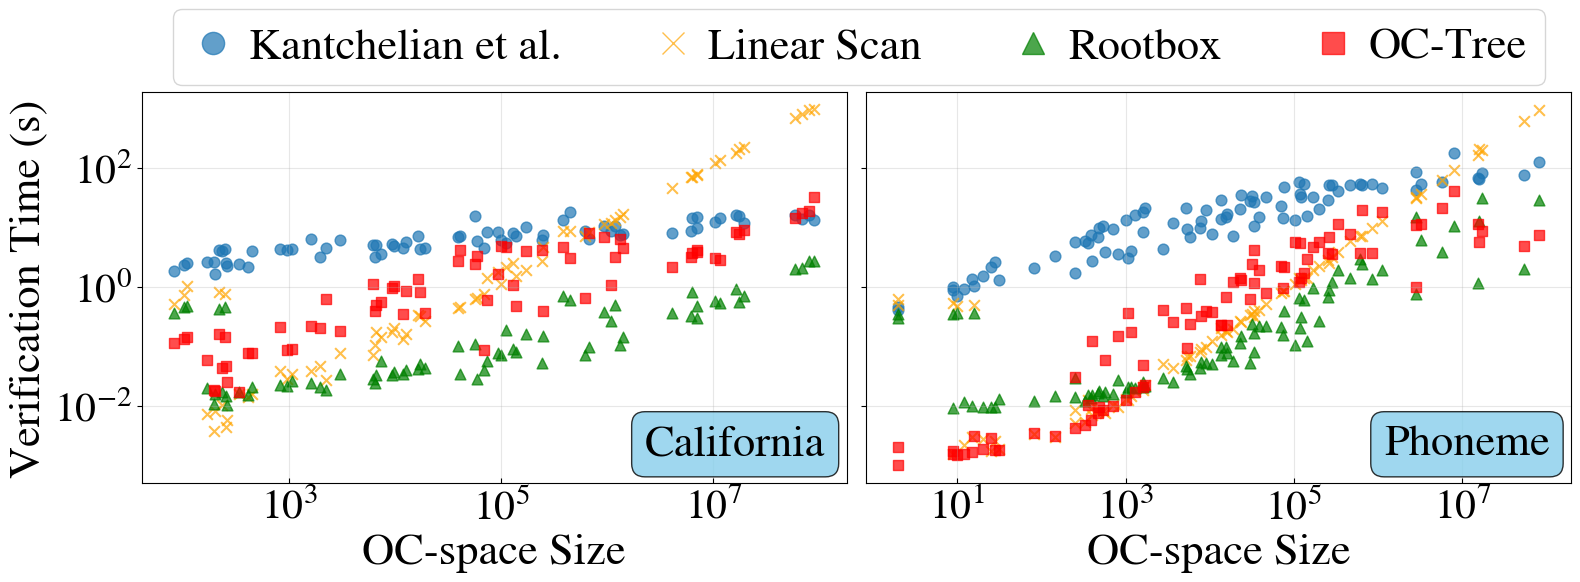

In [61]:
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# datasets_to_include = ['Credit', 'Adult', 'Vehicle', 'Spambase', 'Phoneme', 'DryBean[6vRest]', 'Volkert[2v7]', 'California', 'CompasTwoYears']
datasets_to_include = ['California', 'Phoneme']


# Calculate grid dimensions
n_datasets = len(datasets_to_include)
n_cols = min(2, n_datasets)  # Max 2 columns
n_rows = (n_datasets + n_cols - 1) // n_cols  # Calculate rows needed

# Create subplots in matrix format
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 6*n_rows))

# Handle single subplot case
if n_datasets == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# Flatten for easier indexing
axes_flat = axes.flatten() if n_datasets > 1 else axes

for d, ds in enumerate(sorted(datasets_to_include)):
    verified_results = [(key, value) for key, value in closest_adv_results.items() if value['dname'] == ds and not value['verification'].get('failed_oc', False)]

    oc_space_sizes = [enumeration_results[k]['enumeration']['oc_space'] for k, _ in verified_results]
    kantchelian_times = [r['verification']['kantchelian']['emp_rob_time'] for _, r in verified_results]
    linear_scan_times = [r['verification']['linear_scan']['emp_rob_time'] for _, r in verified_results]
    rootbox_times = [r['verification']['rootbox_index']['emp_rob_time'] for _, r in verified_results]
    oc_index_times = [r['verification']['octree_index']['emp_rob_time'] for _, r in verified_results]


    axes_flat[d].scatter(oc_space_sizes, kantchelian_times,  label='Kantchelian et al.', alpha=0.7, s=60)
    axes_flat[d].scatter(oc_space_sizes, linear_scan_times, marker='x', color='orange', label='Linear Scan', alpha=0.7, s=60)
    axes_flat[d].scatter(oc_space_sizes, rootbox_times, marker='^', color='green', label='Rootbox index', alpha=0.7, s=60)
    axes_flat[d].scatter(oc_space_sizes, oc_index_times, marker='s', color='red', label='OCTree index', alpha=0.7, s=60)
    # axes_flat[d].scatter(oc_space_sizes, veritas_times, marker='d', color='purple', label='Veritas', alpha=0.7, s=60)
    axes_flat[d].text(0.97, 0.05, f"{ds_names[ds]}", transform=axes_flat[d].transAxes, 
                      verticalalignment='bottom', horizontalalignment='right',
                      bbox=dict(boxstyle='round', facecolor='skyblue', alpha=0.8), fontsize=32)
    axes_flat[d].set_xlabel('OC-space Size', fontsize=32)
    axes_flat[d].grid(True, alpha=0.3 )
    
            
    axes_flat[d].set_xscale('log')
    axes_flat[d].set_yscale('log')
    axes_flat[d].tick_params(axis='both', which='major', labelsize=30)
    # Only show y-axis label and ticks on leftmost plots
    if d % n_cols == 0:  # leftmost column
        axes_flat[d].set_ylabel('Verification Time (s)', fontsize=32)
    else:
        axes_flat[d].tick_params(labelleft=False)

    # Only keep x-axis label on the bottom row (bottom two plots for 2 columns)
    if d < len(datasets_to_include) - n_cols:
        axes_flat[d].set_xlabel('')
    else:
        axes_flat[d].set_xlabel('OC-space Size', fontsize=32)

    # After the last subplot is populated, force a common y-range across all subplots
    if d == len(datasets_to_include) - 1:
        y_lims = [ax.get_ylim() for ax in axes_flat[:len(datasets_to_include)]]
        common_ymin = min(lim[0] for lim in y_lims if lim[0] > 0)
        common_ymax = max(lim[1] for lim in y_lims)

        for ax in axes_flat[:len(datasets_to_include)]:
            ax.set_ylim(common_ymin, common_ymax)

        # Remove extra empty axes (if grid > number of datasets)
        for ax in axes_flat[len(datasets_to_include):]:
            ax.set_visible(False)

    

import matplotlib.patches as mpatches
kantchelian_line = Line2D([0], [0], marker='o', label='Kantchelian et al.', linestyle='None', markersize=16, alpha=0.7,)
linear_scan_line = Line2D([0], [0], marker='x', color='orange', label='Linear Scan', linestyle='None', markersize=16, alpha=0.7,)
rootbox_line = Line2D([0], [0], marker='^', color='green', label='Rootbox', linestyle='None', markersize=16, alpha=0.7,)
oc_index_line = Line2D([0], [0], marker='s', color='red', label='OC-Tree', linestyle='None', markersize=16, alpha=0.7,)
fig.tight_layout(rect=[0, 0, 1, 0.85])

color_legend = fig.legend(handles=[kantchelian_line, linear_scan_line, rootbox_line, oc_index_line], 
                         loc='upper center', bbox_to_anchor=(0.54, 1.0), ncol=4, fontsize=32)


plt.savefig('../plots/adversarial_robustness_comparison_subset.pdf', dpi=300)


In [62]:
# Count how often Rootbox / OC-Tree are faster than Kantchelian (per-model comparison)
rootbox_faster = 0
octree_faster = 0
compared = 0

def mean_time(entry):
    if not isinstance(entry, dict):
        return None
    arr = entry.get("individual_verification_times")
    if arr:
        try:
            return float(np.mean(arr))
        except Exception:
            pass

    return None

for item in closest_adv_results.values():
    vr = item.get("verification", {}) or {}
    kant = mean_time(vr.get("kantchelian", {}))
    root = mean_time(vr.get("rootbox_index", {}))
    octree = mean_time(vr.get("octree_index", {}))

    if kant is None:
        continue
    # compare when other method time is available
    if root is not None:
        compared += 1
        if root < kant:
            rootbox_faster += 1
    if octree is not None:
        # count separately (do not increment compared again)
        if octree < kant:
            octree_faster += 1

print(f"Compared models (rootbox vs kantchelian): {compared}")
print(f"Rootbox faster than Kantchelian: {rootbox_faster} ({rootbox_faster/compared*100:.1f}%)")
print(f"OC-Tree faster than Kantchelian: {octree_faster} ({octree_faster/compared*100:.1f}%)")

Compared models (rootbox vs kantchelian): 481
Rootbox faster than Kantchelian: 466 (96.9%)
OC-Tree faster than Kantchelian: 421 (87.5%)


In [63]:
# Average speedup of index-based methods vs Kantchelian
rootbox_speedups = []
octree_speedups = []

for r in closest_adv_results.values():
    vr = r.get("verification", {}) or {}
    if vr.get("failed_oc", False):
        continue

    kant_times = vr.get("kantchelian", {}).get("individual_verification_times")
    root_times = vr.get("rootbox_index", {}).get("individual_verification_times")
    oct_times = vr.get("octree_index", {}).get("individual_verification_times")

    if kant_times:
        kant_mean = float(np.mean(kant_times))

        if root_times:
            root_mean = float(np.mean(root_times))
            if root_mean > 0:
                rootbox_speedups.append(kant_mean / root_mean)

        if oct_times:
            oct_mean = float(np.mean(oct_times))
            if oct_mean > 0:
                octree_speedups.append(kant_mean / oct_mean)

if rootbox_speedups:
    print(f"Rootbox vs Kantchelian avg speedup: {np.mean(rootbox_speedups):.2f}x (n={len(rootbox_speedups)})")
else:
    print("No comparable Rootbox vs Kantchelian runs found.")

if octree_speedups:
    print(f"OC-Tree vs Kantchelian avg speedup: {np.mean(octree_speedups):.2f}x (n={len(octree_speedups)})")
else:
    print("No comparable OC-Tree vs Kantchelian runs found.")

Rootbox vs Kantchelian avg speedup: 87.80x (n=481)
OC-Tree vs Kantchelian avg speedup: 185.43x (n=481)


In [64]:

import numpy as np


summary_data = []
rootbox_not_counted = 0
octree_not_counted = 0
for dname in sorted(set(result['dname'] for result in closest_adv_results.values())):
    verified_results = [r for r in closest_adv_results.values() if r['dname'] == dname and not r['verification'].get('failed_oc', False)]
    
    rootbox_nb_to_amortize = []
    octree_nb_to_amortize = []
    for r in verified_results:
        key = f"{r['dname']}_{r['params']['n_estimators']}_{r['params']['max_depth']}_{r['params']['learning_rate']}_{r['fold']}"
        rootbox_ver_times = r['verification']['rootbox_index']['individual_verification_times']
        octree_ver_times = r['verification']['octree_index']['individual_verification_times']
        kantchelian_ver_times = r['verification']['kantchelian']['individual_verification_times']
        
        rootbox_diff = np.array(kantchelian_ver_times) - np.array(rootbox_ver_times)
        octree_diff = np.array(kantchelian_ver_times) - np.array(octree_ver_times)

        enumeration_time = enumeration_results[key]['enumeration']['elapsed']
        rootbox_index_time = r['verification']['rootbox_index']['index_building_time']
        octree_index_time = r['verification']['octree_index']['index_building_time']

        rootbox_upfront_cost = rootbox_index_time + enumeration_time
        octree_upfront_cost = octree_index_time + enumeration_time

        rootbox_nb_to_amortize.append(rootbox_upfront_cost/np.mean(rootbox_diff))
        octree_nb_to_amortize.append(octree_upfront_cost/np.mean(octree_diff))

    rootbox_nb_to_amortize = np.array(rootbox_nb_to_amortize)
    octree_nb_to_amortize = np.array(octree_nb_to_amortize)
    # print(nb_to_amortize)

    rootbox_not_counted += np.sum(rootbox_nb_to_amortize <= 0)
    octree_not_counted += np.sum(octree_nb_to_amortize <= 0)
    summary_data.append({
        'Dataset': ds_names.get(dname, dname),
        'Rootbox': np.nanmean(rootbox_nb_to_amortize[rootbox_nb_to_amortize > 0]),  # Only consider models where rootbox is faster
        'OC-Tree': np.nanmean(octree_nb_to_amortize[octree_nb_to_amortize > 0])   # Only consider models where octree is faster
    })

summary_df = pd.DataFrame(summary_data)

In [65]:
print(summary_df.to_latex(index=False, float_format="%.0f", caption="Empirical number of verification queries required to amortize the enumeration and index (Rootbox and OC-Tree) construction  cost relative to Kantchelian et al.’s MILP approach, reported per dataset for which all models could be enumerated within 24 hours. Values are computed as described in Appendix~\\ref{appendix:results:sec:special-purpose}.", label="tab:amortization_estimate"))
print(f"Rootbox pct not counted (Kantchelian faster): {rootbox_not_counted / len(closest_adv_results) * 100:.1f}%") # When Kantchelian is faster, we cannot amortize (negative speedup), so we count those cases separately to report how often this happens
print(f"OC-Tree pct not counted (Kantchelian faster): {octree_not_counted / len(closest_adv_results) * 100:.1f}%")

\begin{table}
\caption{Empirical number of verification queries required to amortize the enumeration and index (Rootbox and OC-Tree) construction  cost relative to Kantchelian et al.’s MILP approach, reported per dataset for which all models could be enumerated within 24 hours. Values are computed as described in Appendix~\ref{appendix:results:sec:special-purpose}.}
\label{tab:amortization_estimate}
\begin{tabular}{lrr}
\toprule
Dataset & Rootbox & OC-Tree \\
\midrule
Adult & 1022 & 1830 \\
California & 2175 & 4892 \\
Compas & 1537 & 8492 \\
Credit & 726 & 903 \\
DryBean & 1006 & 829 \\
Phoneme & 869 & 718 \\
Spambase & 4146 & 26437 \\
Vehicle & 2857 & 2331 \\
Volkert & 3244 & 2191 \\
\bottomrule
\end{tabular}
\end{table}

Rootbox pct not counted (Kantchelian faster): 3.1%
OC-Tree pct not counted (Kantchelian faster): 12.5%


## Fairness

In [66]:
fairness_file = '../results/fairness.txt'
fairness_results = {}
with open(fairness_file, 'r') as file: #Load in the fairness results
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        fairness_results[key] = line_dict

/tmp/ipykernel_282033/824012194.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_282033/824012194.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=15)
/tmp/ipykernel_282033/824012194.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_282033/824012194.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=15)


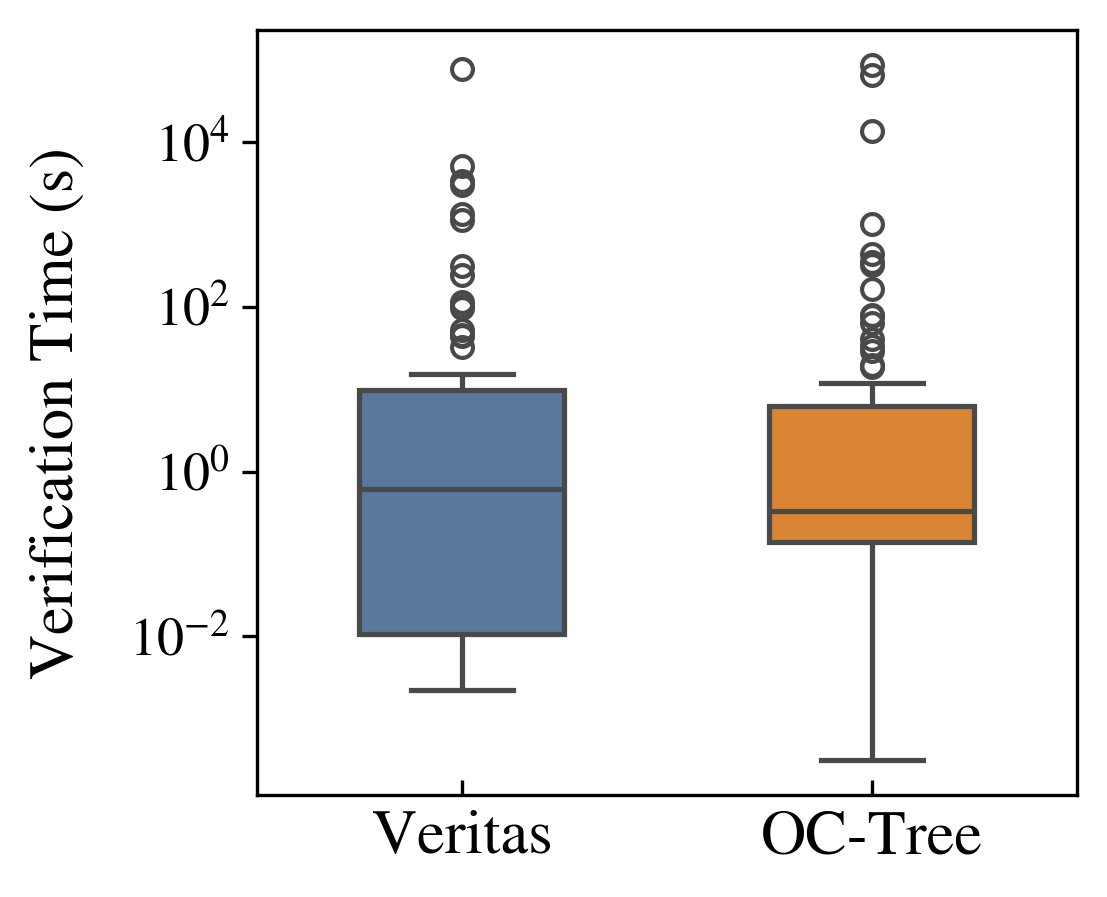

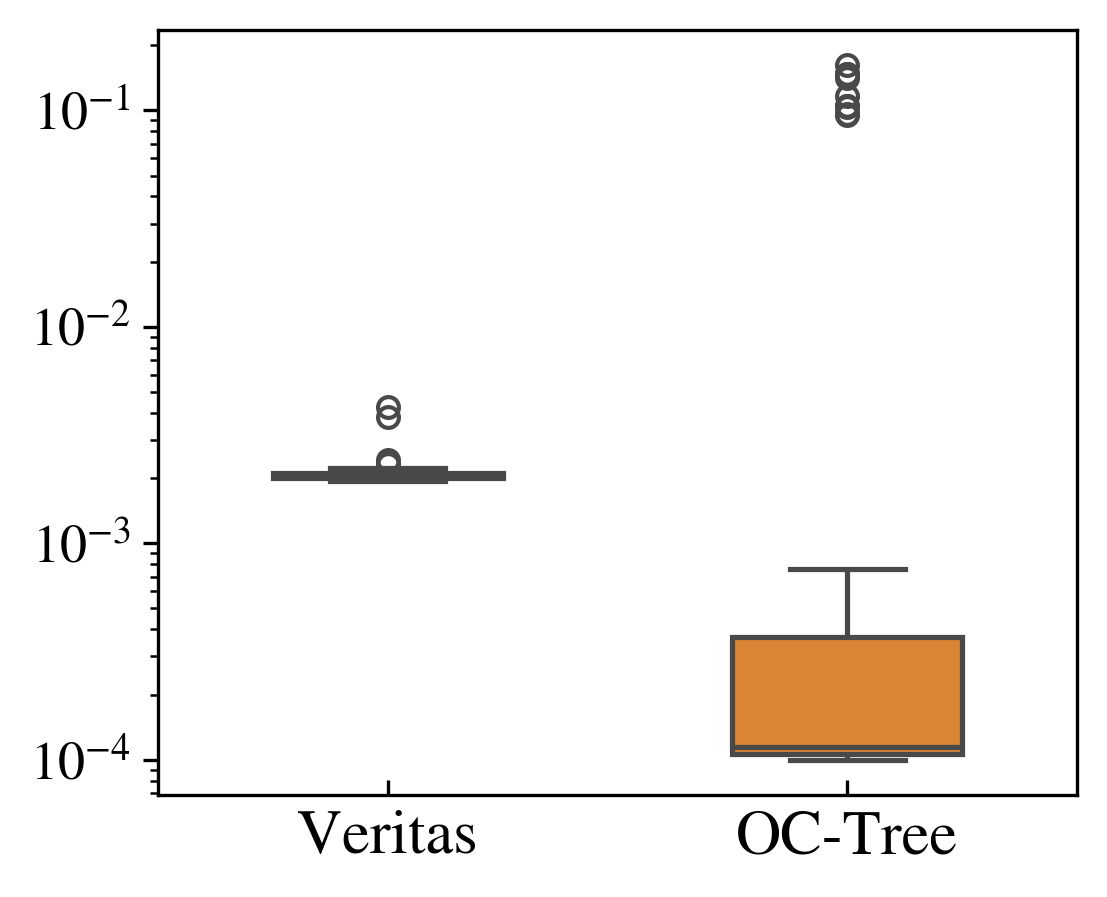

In [67]:
import seaborn as sns
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

# Collect runtimes per dataset and per method
runtime_by_dataset = {}

for result in fairness_results.values():
    dname = result.get("dname")
    verification = result.get("verification", {})
    if dname is None:
        continue

    if dname not in runtime_by_dataset:
        runtime_by_dataset[dname] = {"Veritas": [], "OC-Tree": []}

    
    ver = verification.get("veritas_search", {})
    idx = verification.get("index_based", {})

    if "time" in idx or "index_time" in idx:
        runtime_by_dataset[dname]["OC-Tree"].append(idx.get("time", idx.get("index_time")))

    if "time" in ver:
        runtime_by_dataset[dname]["Veritas"].append(ver["time"])

plt.style.use("../stylesheet.mplstyle")  

for ds in runtime_by_dataset:
    # Use the same external style file
    

    # Paper-sized figure and constrained layout, same palette and options
    fig, ax = plt.subplots(figsize=(3.5, 2.8), dpi=300, layout="constrained")

    palette = ["#4C78A8", "#F58518"]  # blue, orange

    plot_df = (
        pd.DataFrame(runtime_by_dataset[ds])
        .melt(var_name="Method", value_name="Runtime")
        .dropna()
    )

    sns.boxplot(
        data=plot_df,
        x="Method",
        y="Runtime",
        palette=palette,
        width=0.5,
        linewidth=1.25,
        showfliers=True,
        fliersize=5,
        ax=ax
    )
    ax.set_yscale("log")
    ax.set_xlabel("")
    if ds == "Adult":
        ax.set_ylabel("Verification Time (s)", fontsize=15)
    else:
        ax.set_ylabel(f"")
    ax.yaxis.set_major_locator(plt.LogLocator(base=10.0, numticks=6))
    ax.tick_params(axis='y', which='major', labelsize=13)
    ax.yaxis.labelpad = 10
    ax.tick_params(axis='x', labelsize=13)
    # yticks slightly closer to y-axis
    ax.yaxis.set_tick_params(pad=3)

    # Adjust font size for boxplot names
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=15)

    plt.savefig(f"../plots/fairness_runtime_comparison{ds}.pdf", dpi=300, bbox_inches="tight")

In [68]:
# Calculate average fairness speedup for OC-Tree vs Veritas
fairness_speedups = []

for result in fairness_results.values():
    verification = result.get("verification", {})
    veritas_search = verification.get("veritas_search", {})
    index_based = verification.get("index_based", {})
    
    t_veritas = veritas_search.get("time")
    t_octree = index_based.get("time")
    
    if t_veritas is None or t_octree is None or t_octree == 0:
        continue
    
    speedup = t_veritas / t_octree
    fairness_speedups.append(speedup)

if fairness_speedups:
    avg_speedup = np.mean(fairness_speedups)
    median_speedup = np.median(fairness_speedups)
    min_speedup = np.min(fairness_speedups)
    max_speedup = np.max(fairness_speedups)
    
    print(f"Average fairness speedup (Veritas vs OC-Tree): {avg_speedup:.2f}x")
    print(f"Median fairness speedup (Veritas vs OC-Tree): {median_speedup:.2f}x")
    print(f"Min speedup: {min_speedup:.2f}x")
    print(f"Max speedup: {max_speedup:.2f}x")
    print(f"Total fairness verification runs: {len(fairness_speedups)}")
else:
    print("No comparable fairness verification runs found")

Average fairness speedup (Veritas vs OC-Tree): 7.97x
Median fairness speedup (Veritas vs OC-Tree): 4.04x
Min speedup: 0.01x
Max speedup: 56.56x
Total fairness verification runs: 125


In [69]:
# Count how often each method is faster (only on runs where both times are available)
overall = {"OC-Tree faster": 0, "Veritas faster": 0, "Ties": 0, "Comparable runs": 0}
per_dataset = []

for dname in sorted(set(r["dname"] for r in fairness_results.values())):
    ds_runs = [r for r in fairness_results.values() if r["dname"] == dname]
    oc_faster = ver_faster = ties = comparable = 0

    for r in ds_runs:
        vr = r.get("verification", {}) or {}
        ver = vr.get("veritas_search", {})
        idx = vr.get("index_based", {})

        t_ver = ver.get("time")
        t_idx = idx.get("time", idx.get("index_time"))

        if t_ver is None or t_idx is None:
            continue

        t_ver, t_idx = float(t_ver), float(t_idx)
        comparable += 1

        if t_idx < t_ver:
            oc_faster += 1
        elif t_ver < t_idx:
            ver_faster += 1
        else:
            ties += 1

    overall["OC-Tree faster"] += oc_faster
    overall["Veritas faster"] += ver_faster
    overall["Ties"] += ties
    overall["Comparable runs"] += comparable

    per_dataset.append({
        "Dataset": ds_names.get(dname, dname),
        "Comparable runs": comparable,
        "OC-Tree faster": oc_faster,
        "Veritas faster": ver_faster,
        "Ties": ties,
    })

speed_counts_df = pd.DataFrame(per_dataset).sort_values("Dataset").reset_index(drop=True)

print("Overall counts:", overall)
display(speed_counts_df)

Overall counts: {'OC-Tree faster': 80, 'Veritas faster': 45, 'Ties': 0, 'Comparable runs': 125}


,Dataset,Comparable runs,OC-Tree faster,Veritas faster,Ties
0,Adult,70,36,34,0
1,Compas,55,44,11,0


In [70]:
# Create detailed fairness results table for Adult dataset
adult_fairness_data = []

for result in fairness_results.values():
    if result.get("dname") != "Adult":
        continue
    
    params = result.get("params", {})
    verification = result.get("verification", {})
    
    veritas_search = verification.get("veritas_search", {})
    index_based = verification.get("index_based", {})
    
    lr = params.get("learning_rate")
    # Format learning rate to one of: 0.1, 0.25, 0.5, 1.0
    lr_formatted = {0.1: "0.1", 0.25: "0.25", 0.5: "0.5", 1.0: "1.0"}.get(lr, str(lr))
    
    adult_fairness_data.append({
        "M": params.get("n_estimators"),
        "D": params.get("max_depth"),
        "LR": lr_formatted,
        "Fold": result.get("fold"),
        "Unfair Boxes": veritas_search.get("num_violating_regions", "-"),
        "Veritas Time (s)": f"{veritas_search.get('time'):.3f}" if veritas_search.get("time") else "-",
        "OC-Tree Time (s)": f"{index_based.get('time'):.3f}" if index_based.get("time") else "-",
    })

adult_fairness_df = pd.DataFrame(adult_fairness_data)
adult_fairness_df = adult_fairness_df.sort_values(["M", "D", "LR", "Fold"]).reset_index(drop=True)

caption = "Detailed results for fairness verification on the Adult dataset. The first column indicates the hyperparameters used to learn the uncompressed model (M: \\#Trees, D: Max depth, LR: Learning rate). We report the fold, number of boxes where the model is unfair and verification time of Veritas and OC-Tree search (in seconds)."

print(adult_fairness_df.to_latex(
    index=False,
    caption=caption,
    label="tab:fairness_adult_detailed"
))

\begin{table}
\caption{Detailed results for fairness verification on the Adult dataset. The first column indicates the hyperparameters used to learn the uncompressed model (M: \#Trees, D: Max depth, LR: Learning rate). We report the fold, number of boxes where the model is unfair and verification time of Veritas and OC-Tree search (in seconds).}
\label{tab:fairness_adult_detailed}
\begin{tabular}{rrlrrll}
\toprule
M & D & LR & Fold & Unfair Boxes & Veritas Time (s) & OC-Tree Time (s) \\
\midrule
10 & 4 & 0.5 & 0 & 11 & 0.640 & 0.158 \\
10 & 4 & 0.5 & 1 & 25 & 0.767 & 0.139 \\
10 & 4 & 0.5 & 2 & 35 & 0.004 & 0.141 \\
10 & 4 & 0.5 & 3 & 395 & 0.111 & 0.148 \\
10 & 4 & 0.5 & 4 & 30 & 0.036 & 0.146 \\
10 & 4 & 1.0 & 0 & 646 & 0.429 & 0.328 \\
10 & 4 & 1.0 & 1 & 18977 & 11.581 & 3.599 \\
10 & 4 & 1.0 & 2 & 303 & 0.211 & 0.190 \\
10 & 4 & 1.0 & 3 & 20 & 0.008 & 0.146 \\
10 & 4 & 1.0 & 4 & 553 & 0.121 & 0.155 \\
10 & 6 & 0.1 & 0 & 0 & 0.004 & 0.000 \\
10 & 6 & 0.1 & 1 & 2 & 0.002 & 0.122 \\
1

In [71]:
# Create detailed fairness results table for CompasTwoYears dataset
compas_two_years_fairness_data = []

def fmt_time(t):
    return f"{float(t):.2e}" if t is not None else "-"

for result in fairness_results.values():
    if result.get("dname") != "CompasTwoYears":
        continue
    
    params = result.get("params", {})
    verification = result.get("verification", {})
    
    veritas_search = verification.get("veritas_search", {})
    index_based = verification.get("index_based", {})
    
    lr = params.get("learning_rate")
    lr_formatted = {0.1: "0.1", 0.25: "0.25", 0.5: "0.5", 1.0: "1.0"}.get(lr, str(lr))
    
    compas_two_years_fairness_data.append({
        "M": params.get("n_estimators"),
        "D": params.get("max_depth"),
        "LR": lr_formatted,
        "Fold": result.get("fold"),
        "Unfair Boxes": veritas_search.get("num_violating_regions", "-"),
        "Veritas Time (s)": fmt_time(veritas_search.get("time")),
        "OC-Tree Time (s)": fmt_time(index_based.get("time")),
    })

compas_two_years_fairness_df = pd.DataFrame(compas_two_years_fairness_data)
compas_two_years_fairness_df = compas_two_years_fairness_df.sort_values(["M", "D", "LR", "Fold"]).reset_index(drop=True)

caption = "Detailed results for fairness verification on the CompasTwoYears dataset. The first column indicates the hyperparameters used to learn the uncompressed model (M: \\#Trees, D: Max depth, LR: Learning rate). We report the fold, number of boxes where the model is unfair and verification time of Veritas and OC-Tree search (in seconds)."

print(compas_two_years_fairness_df.to_latex(
    index=False,
    caption=caption,
    label="tab:fairness_compas_two_years_detailed"
))

\begin{table}
\caption{Detailed results for fairness verification on the CompasTwoYears dataset. The first column indicates the hyperparameters used to learn the uncompressed model (M: \#Trees, D: Max depth, LR: Learning rate). We report the fold, number of boxes where the model is unfair and verification time of Veritas and OC-Tree search (in seconds).}
\label{tab:fairness_compas_two_years_detailed}
\begin{tabular}{rrlrrll}
\toprule
M & D & LR & Fold & Unfair Boxes & Veritas Time (s) & OC-Tree Time (s) \\
\midrule
25 & 4 & 0.25 & 0 & 0 & 3.84e-03 & 4.13e-04 \\
25 & 4 & 0.25 & 1 & 2 & 2.03e-03 & 1.62e-01 \\
25 & 4 & 0.25 & 2 & 6 & 2.13e-03 & 1.48e-01 \\
25 & 4 & 0.25 & 3 & 3 & 2.07e-03 & 1.48e-01 \\
25 & 4 & 0.25 & 4 & 0 & 2.00e-03 & 3.31e-04 \\
25 & 4 & 0.5 & 0 & 0 & 1.94e-03 & 2.41e-04 \\
25 & 4 & 0.5 & 1 & 0 & 2.04e-03 & 1.16e-04 \\
25 & 4 & 0.5 & 2 & 0 & 2.02e-03 & 3.81e-04 \\
25 & 4 & 0.5 & 3 & 1 & 2.03e-03 & 1.04e-01 \\
25 & 4 & 0.5 & 4 & 1 & 2.08e-03 & 1.17e-01 \\
25 & 4 & 1.0 &

# Funky norm

In [72]:
funky_norm_file = '../results/funky_norm.txt'
funky_norm_results = {}
with open(funky_norm_file, 'r') as file: #Load in the funky norm results
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        funky_norm_results[key] = line_dict

In [73]:
import numpy as np

# Compare rootbox vs any SMT-based method in funky_norm_results
rootbox_wins = smt_wins = ties = comparable = 0

# print(funky_norm_results.values())
for r in funky_norm_results.values():
    vr = r.get("funky_norm", {})
    # print(vr.get('verification_results', {}))
    root = vr.get('verification_results', {}).get('index', {}).get('time', None)
    smt = vr.get('verification_results', {}).get('smt', {}).get('time', None)
    # find any SMT-like entry

    if root is None or smt is None:
        continue
    comparable += 1
    if root < smt:
        rootbox_wins += 1
    elif smt < root:
        smt_wins += 1
    else:
        ties += 1

if comparable == 0:
    print("No comparable runs (both rootbox and SMT times unavailable).")
else:
    print(f"Comparable runs: {comparable}")
    print(f"Rootbox faster: {rootbox_wins} ({rootbox_wins/comparable*100:.1f}%)")
    print(f"SMT faster: {smt_wins} ({smt_wins/comparable*100:.1f}%)")
    print(f"Ties: {ties} ({ties/comparable*100:.1f}%)")

Comparable runs: 154
Rootbox faster: 154 (100.0%)
SMT faster: 0 (0.0%)
Ties: 0 (0.0%)


In [74]:
import numpy as np

# Calculate how much faster rootbox is than smt on average

speedup_factors = []
time_saved = []

for r in funky_norm_results.values():
    vr = r.get("funky_norm", {})
    root = vr.get('verification_results', {}).get('index', {}).get('time', None)
    smt = vr.get('verification_results', {}).get('smt', {}).get('time', None)
    
    if root is None or smt is None or root == 0:
        continue
    
    speedup = smt / root  # how many times faster
    saved = smt - root
    
    speedup_factors.append(speedup)
    time_saved.append(saved)

if speedup_factors:
    avg_speedup = np.mean(speedup_factors)
    median_speedup = np.median(speedup_factors)
    avg_time_saved = np.mean(time_saved)
    
    print(f"Average speedup (Rootbox vs SMT): {avg_speedup:.2f}x")
    print(f"Median speedup (Rootbox vs SMT): {median_speedup:.2f}x")
    print(f"Average time saved: {avg_time_saved:.4f}s")
    print(f"Rootbox wins: {rootbox_wins}/{comparable}")
else:
    print("No comparable runs available")

Average speedup (Rootbox vs SMT): 742.52x
Median speedup (Rootbox vs SMT): 698.50x
Average time saved: 26.8491s
Rootbox wins: 154/154
